# LendingClub Interest Rate EDA — `true data/`
**Goal:** Understand the structure, quality, and signal in `true data/LC_train.csv` (100k loans, 39 cols) before modeling `int_rate`. This EDA is application-time honest: it uses the data dictionary to verify what each field means, keeps raw inputs separate from safe analysis frames, and excludes fields unavailable at origination.
- **FICO scores are present** (`fico_range_low`, `fico_range_high`) — they were stripped from the prior slice
- **`loan_status` is present** — a post-origination status field; excluded because it is unavailable at application time
- **No date columns** (no `issue_d`, no `earliest_cr_line`) — temporal validation is not possible on this slice
- **No `grade`, `sub_grade`, or `installment`** — the obvious pre-origination leakage trio is gone
- Several numerics arrive as strings (`dti`, `revol_util`, `all_util`, `mths_since_*`, `mo_sin_old_il_acct`) with literal `"NA"` for nulls — cast at load time
This notebook does NOT fit models. It uses only diagnostic derived fields needed to audit relationships and recommend modeling choices.

## 0. Setup

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

# Path resolution works whether run from notebooks/ or project root.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "true data"
DICTIONARY_PATH = DATA_DIR / "LCDataDictionary.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str, fig=None):
    fig = fig or plt.gcf()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{name}.png")
    return OUTPUT_DIR / f"{name}.png"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_DIR     = {DATA_DIR}")
print(f"DICTIONARY   = {DICTIONARY_PATH}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")

PROJECT_ROOT = C:\Users\liula\Documents\applied ai\project 1
DATA_DIR     = C:\Users\liula\Documents\applied ai\project 1\true data
DICTIONARY   = C:\Users\liula\Documents\applied ai\project 1\true data\LCDataDictionary.xlsx
OUTPUT_DIR   = C:\Users\liula\Documents\applied ai\project 1\outputs\eda


In [2]:
# Numeric columns the CSV stores as strings (e.g. "26.33", "NA"). Polars
# reads them as String unless overridden. The "NA" literal is handled by
# passing null_values=["NA"] to pl.read_csv.
STRING_NUMERIC_COLS = [
    "dti", "revol_util", "all_util",
    "mo_sin_old_il_acct",
    "mths_since_last_record", "mths_since_rcnt_il",
    "mths_since_recent_bc", "mths_since_recent_inq",
]
# tot_cur_bal arrives as Float64 in train but Int64 in test — force Float64
# in both for parity.
NUMERIC_OVERRIDES = {c: pl.Float64 for c in STRING_NUMERIC_COLS + ["tot_cur_bal"]}

# loan_status is the current lifecycle status of the loan. The data dictionary
# confirms it is not an application input, so it is unavailable at origination.
# It must be excluded from application-time EDA and modeling even if its
# marginal relationship with int_rate is modest.
LEAKAGE_COLS_POST_ORIGINATION = ["loan_status"]

# Categoricals to treat as native XGBoost categoricals (no one-hot).
CATEGORICAL_COLS = [
    "home_ownership", "verification_status", "purpose",
    "application_type", "addr_state", "term",
]

# emp_length ordinal map — same as the archived pipeline.
EMP_LENGTH_MAP = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10, "n/a": None,
}

## 1. Schema & data quality audit

Load raw train/test with `null_values=["NA"]` and Float64 overrides for the string-encoded numeric columns. Bridge to pandas. Verify shapes, dictionary coverage, dtype parity, ID uniqueness, target absence in test, and observed encodings. (No `issue_d` exists, so no chronological ordering check.)

In [3]:
train_raw = pl.read_csv(
    DATA_DIR / "LC_train.csv",
    schema_overrides=NUMERIC_OVERRIDES,
    null_values=["NA"],
    infer_schema_length=20000,
).to_pandas()

test_raw = pl.read_csv(
    DATA_DIR / "LC_test.csv",
    schema_overrides=NUMERIC_OVERRIDES,
    null_values=["NA"],
    infer_schema_length=20000,
).to_pandas()

data_dict = pd.read_excel(DICTIONARY_PATH, sheet_name="LoanStats")
data_dict["Variable Name"] = data_dict["Variable Name"].astype(str)
dict_cols = set(data_dict["Variable Name"])

print(f"train_raw shape: {train_raw.shape}")
print(f"test_raw  shape: {test_raw.shape}")
print(f"dictionary rows: {len(data_dict)}")

assert train_raw.shape == (100_000, 39), f"unexpected train shape: {train_raw.shape}"
assert test_raw.shape == (10_000, 39),   f"unexpected test shape: {test_raw.shape}"
assert "int_rate" in train_raw.columns and "int_rate" not in test_raw.columns
assert "ID" in test_raw.columns and "ID" not in train_raw.columns
assert test_raw["ID"].is_unique and test_raw["ID"].nunique() == len(test_raw)
assert len(data_dict) == 39
assert set(train_raw.columns) == dict_cols
assert set(test_raw.columns) - dict_cols == {"ID"}
assert dict_cols - set(test_raw.columns) == {"int_rate"}
print("Raw schema and dictionary assertions passed.")

schema_audit = pd.DataFrame({
    "check": [
        "train columns covered by dictionary",
        "dictionary columns missing from train",
        "test-only columns outside dictionary",
        "dictionary columns absent from test",
        "test ID unique",
    ],
    "result": [
        len(set(train_raw.columns) & dict_cols),
        sorted(dict_cols - set(train_raw.columns)),
        sorted(set(test_raw.columns) - dict_cols),
        sorted(dict_cols - set(test_raw.columns)),
        bool(test_raw["ID"].is_unique),
    ],
})
display(schema_audit)

train_raw shape: (100000, 39)
test_raw  shape: (10000, 39)
dictionary rows: 39
Raw schema and dictionary assertions passed.


,check,result
0,train columns covered by dictionary,39
1,dictionary columns missing from train,[]
2,test-only columns outside dictionary,[ID]
3,dictionary columns absent from test,[int_rate]
4,test ID unique,True


In [4]:
# Dtype parity check between train and test (excluding the asymmetric int_rate / ID columns)
dtype_train = train_raw.drop(columns=["int_rate"]).dtypes
dtype_test  = test_raw.drop(columns=["ID"]).dtypes
parity = pd.DataFrame({"train": dtype_train, "test": dtype_test})
parity["match"] = parity["train"].astype(str) == parity["test"].astype(str)
mismatches = parity[~parity["match"]]
print(f"Dtype mismatches: {len(mismatches)}")
if len(mismatches):
    display(mismatches)
else:
    print("All shared columns have matching dtypes.")

Dtype mismatches: 0
All shared columns have matching dtypes.


In [5]:
def observed_values(series, max_items=12):
    vals = series.dropna().astype(str).value_counts().head(max_items)
    return ", ".join([f"{repr(k)} ({v:,})" for k, v in vals.items()])

dict_lookup = data_dict.set_index("Variable Name")["Description"].to_dict()
encoding_audit = pd.DataFrame([
    {
        "column": "term",
        "dictionary_expectation": dict_lookup["term"],
        "observed_train_encoding": observed_values(train_raw["term"]),
        "implication": "Strip leading spaces and parse 36/60 into term_months before modeling.",
    },
    {
        "column": "emp_length",
        "dictionary_expectation": dict_lookup["emp_length"],
        "observed_train_encoding": observed_values(train_raw["emp_length"]),
        "implication": "Observed as LendingClub text labels; map with EMP_LENGTH_MAP and treat missing explicitly.",
    },
    {
        "column": "home_ownership",
        "dictionary_expectation": dict_lookup["home_ownership"],
        "observed_train_encoding": observed_values(train_raw["home_ownership"]),
        "implication": "Dictionary allows OTHER, but train/test observe only MORTGAGE/RENT/OWN; encoder should still tolerate OTHER.",
    },
    {
        "column": "loan_status",
        "dictionary_expectation": dict_lookup["loan_status"],
        "observed_train_encoding": observed_values(train_raw["loan_status"]),
        "implication": "Current loan status is not an application-time input; audit only, then drop.",
    },
])
display(encoding_audit)

,column,dictionary_expectation,observed_train_encoding,implication
0,term,The number of payments on the loan. Values are...,"' 36 months' (65,542), ' 60 months' (34,458)",Strip leading spaces and parse 36/60 into term...
1,emp_length,Employment length in years. Possible values ar...,"'10+ years' (28,343), '< 1 year' (13,331), '2 ...",Observed as LendingClub text labels; map with ...
2,home_ownership,The home ownership status provided by the borr...,"'MORTGAGE' (48,114), 'RENT' (39,958), 'OWN' (1...","Dictionary allows OTHER, but train/test observ..."
3,loan_status,Current status of the loan,"'Current' (95,779), 'Fully Paid' (2,738), 'Iss...",Current loan status is not an application-time...


**Schema takeaway:** The raw train file exactly matches the 39-column data dictionary; test differs only by replacing `int_rate` with `ID`. From here on, all signal analysis uses `train_safe` / `test_safe`, where post-origination `loan_status` has been removed.

In [6]:
# *** LEAKAGE GUARD ***
# loan_status is the loan's current lifecycle status, not a borrower/application
# input available when the interest rate is set. We exclude it from all safe
# bivariate/correlation/drift/feature recommendation analysis.
#
# We KEEP a side copy (loan_status_audit) for use only in §8 (leakage audit),
# where we quantify the leakage explicitly. That copy is discarded after §8.
loan_status_audit = train_raw[["loan_status", "int_rate"]].copy()
train_safe = train_raw.drop(columns=LEAKAGE_COLS_POST_ORIGINATION).copy()
test_safe  = test_raw.drop(columns=LEAKAGE_COLS_POST_ORIGINATION).copy()
print(f"Dropped: {LEAKAGE_COLS_POST_ORIGINATION}")
print(f"train_safe shape after availability drop: {train_safe.shape}")
print(f"test_safe shape after availability drop:  {test_safe.shape}")
assert "loan_status" not in train_safe.columns
assert "loan_status" not in test_safe.columns

# Downstream cells use short aliases for the safe application-time frames.
# The raw frames remain available as train_raw/test_raw for schema audits only.
train = train_safe
test = test_safe

Dropped: ['loan_status']
train_safe shape after availability drop: (100000, 38)
test_safe shape after availability drop:  (10000, 38)


In [7]:
# Full-row duplicate check
n_dupes = train_raw.duplicated().sum()
print(f"Full-row duplicates in train: {n_dupes}")

# Confirm no date columns exist (different from the prior data/ slice)
date_like = [c for c in train_raw.columns if any(s in c.lower() for s in ("date", "_d", "issue", "earliest"))]
print(f"Date-like columns: {date_like or 'none — no temporal structure available'}")

Full-row duplicates in train: 0
Date-like columns: none — no temporal structure available


## 2. Target distribution (`int_rate`)

`int_rate` is the APR percentage on each loan. We check shape, central tendency, tail behaviour, and whether a transform (log / sqrt / Box-Cox) would meaningfully reduce skew before modeling.

In [8]:
y = train["int_rate"]
desc = y.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4)
desc["skew"] = y.skew()
desc["kurtosis"] = y.kurtosis()
print(desc.to_string())

count       100000.000000
mean            12.946800
std              5.255600
min              6.460000
1%               6.460000
5%               6.460000
25%              8.190000
50%             11.710000
75%             16.120000
95%             23.050000
99%             28.800000
max             30.990000
skew             0.851097
kurtosis         0.100576


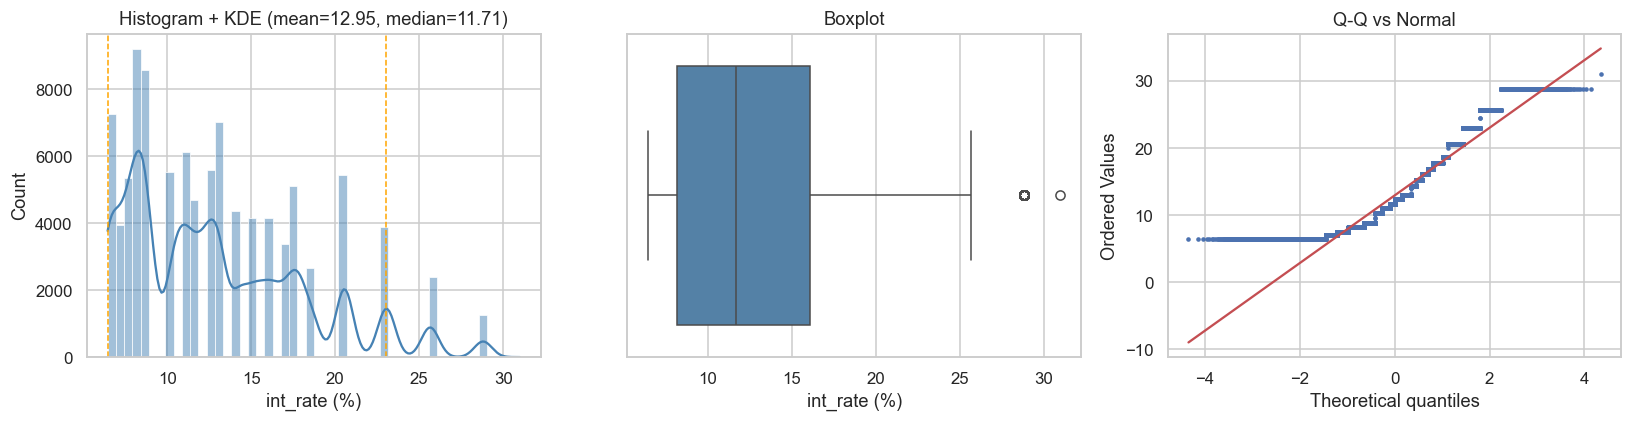

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram + KDE
sns.histplot(y, bins=50, kde=True, ax=axes[0], color="steelblue")
for q in [0.05, 0.95]:
    axes[0].axvline(y.quantile(q), color="orange", linestyle="--", linewidth=1)
axes[0].set_title(f"Histogram + KDE (mean={y.mean():.2f}, median={y.median():.2f})")
axes[0].set_xlabel("int_rate (%)")

# Boxplot
sns.boxplot(x=y, ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot")
axes[1].set_xlabel("int_rate (%)")

# Q-Q vs normal
stats.probplot(y, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q vs Normal")
axes[2].get_lines()[0].set_markersize(2)

save_fig("02_target_distribution")
plt.show()

In [10]:
def report_skew(name, vals):
    print(f"  {name:<15s} skew={stats.skew(vals):+.4f}  kurt={stats.kurtosis(vals):+.4f}")

print("Skew before / after candidate transforms:")
report_skew("identity",  y.values)
report_skew("log1p",     np.log1p(y.values))
report_skew("sqrt",      np.sqrt(y.values))
bc, lam = stats.boxcox(y.values + 1e-6)
report_skew(f"box-cox(λ={lam:.2f})", bc)
print()
print("Recommendation: keep target-transform decisions empirical. Box-Cox/log reduce univariate skew,")
print("but tree ensembles should compare raw vs transformed targets by cross-validation RMSE.")

Skew before / after candidate transforms:
  identity        skew=+0.8511  kurt=+0.1005
  log1p           skew=+0.2320  kurt=-0.9032
  sqrt            skew=+0.5053  kurt=-0.5699
  box-cox(λ=-0.26) skew=+0.0341  kurt=-1.0178

Recommendation: keep target-transform decisions empirical. Box-Cox/log reduce univariate skew,
but tree ensembles should compare raw vs transformed targets by cross-validation RMSE.


**Target takeaway:** `int_rate` is moderately right-skewed but bounded and discrete. A transform can make residuals nicer for some learners, but it is not an EDA mandate; accept it only if validation RMSE improves.

## 3. Missingness analysis

Per-column null counts after the `"NA"` literals have been promoted to true nulls at load time. Without `issue_d` we can't probe the temporal mechanism of missingness — we test the remaining mechanisms: co-occurrence patterns and target correlation of missingness indicators.

In [11]:
null_counts = train.isna().sum().sort_values(ascending=False)
null_pct = (null_counts / len(train) * 100).round(2)
null_table = pd.DataFrame({"n_missing": null_counts, "pct": null_pct})
null_table = null_table[null_table["n_missing"] > 0]
print(f"Columns with any missingness: {len(null_table)}")
display(null_table.head(20))

Columns with any missingness: 10


,n_missing,pct
mths_since_last_record,90875,90.88
emp_title,14920,14.92
mths_since_recent_inq,9975,9.98
emp_length,8669,8.67
mo_sin_old_il_acct,2204,2.20
mths_since_rcnt_il,2204,2.20
mths_since_recent_bc,920,0.92
dti,186,0.19
revol_util,123,0.12
all_util,16,0.02


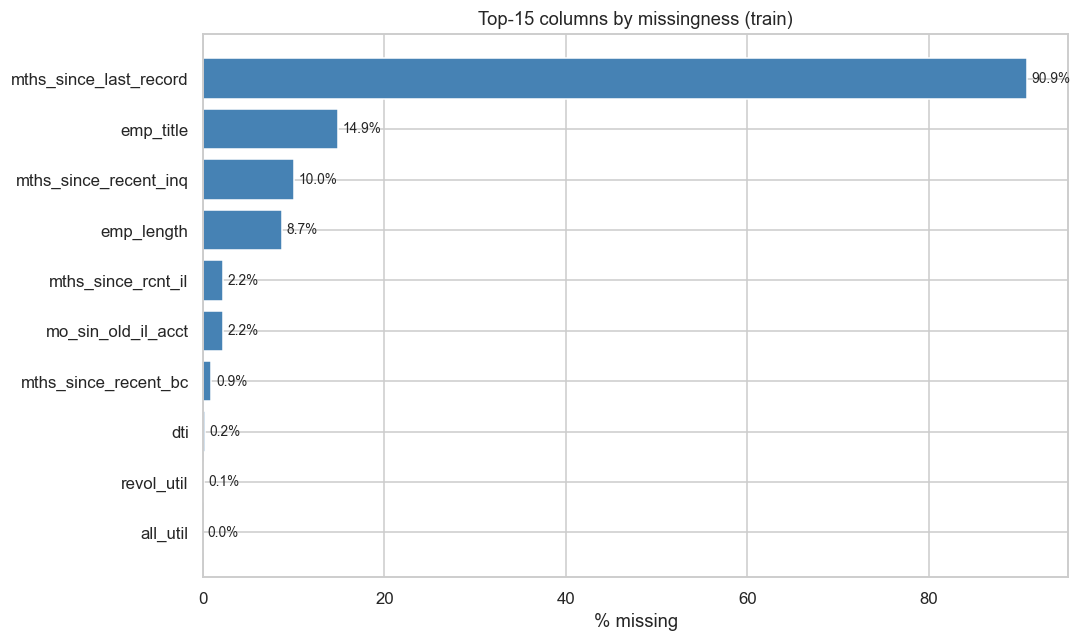

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
top = null_table.sort_values("pct").tail(15)
ax.barh(top.index, top["pct"], color="steelblue")
ax.set_xlabel("% missing")
ax.set_title("Top-15 columns by missingness (train)")
for i, (col, pct) in enumerate(zip(top.index, top["pct"])):
    ax.text(pct + 0.5, i, f"{pct:.1f}%", va="center", fontsize=9)
save_fig("03_missingness_top15")
plt.show()

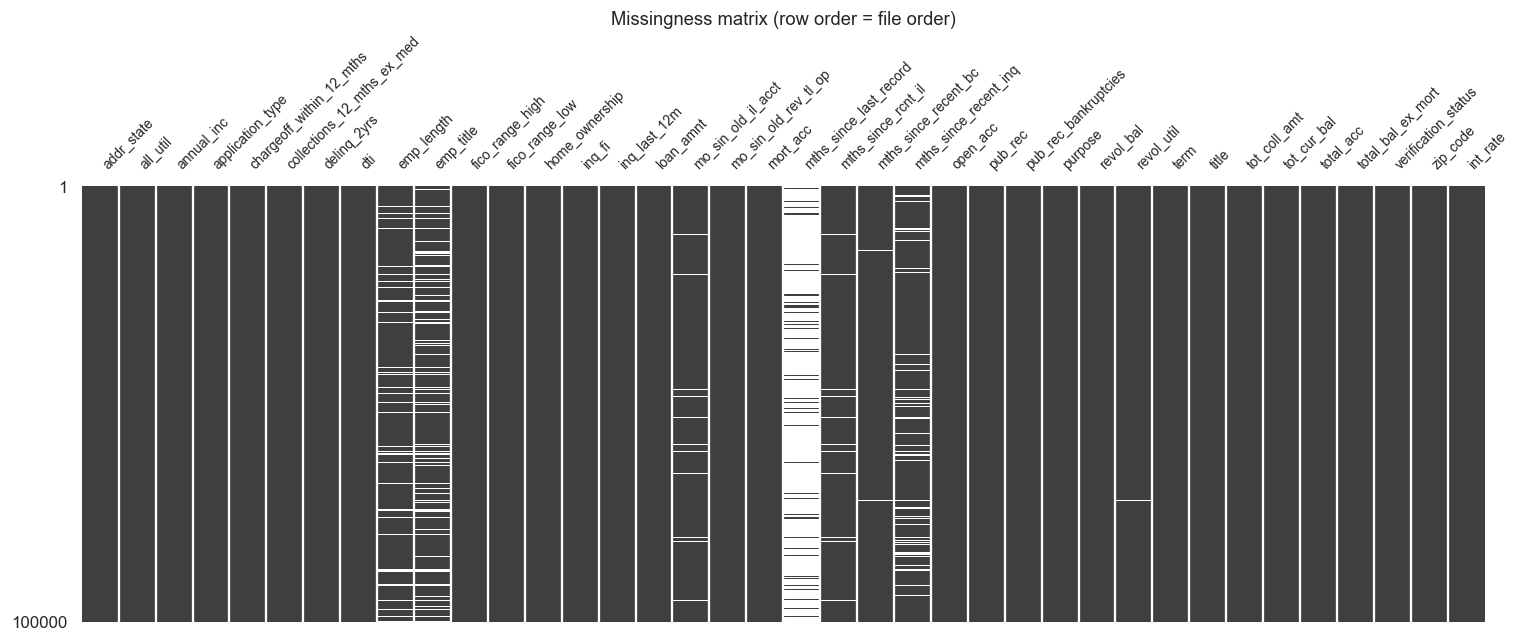

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(train, sparkline=False, ax=ax, fontsize=9)
ax.set_title("Missingness matrix (row order = file order)")
save_fig("03_missingness_matrix")
plt.show()

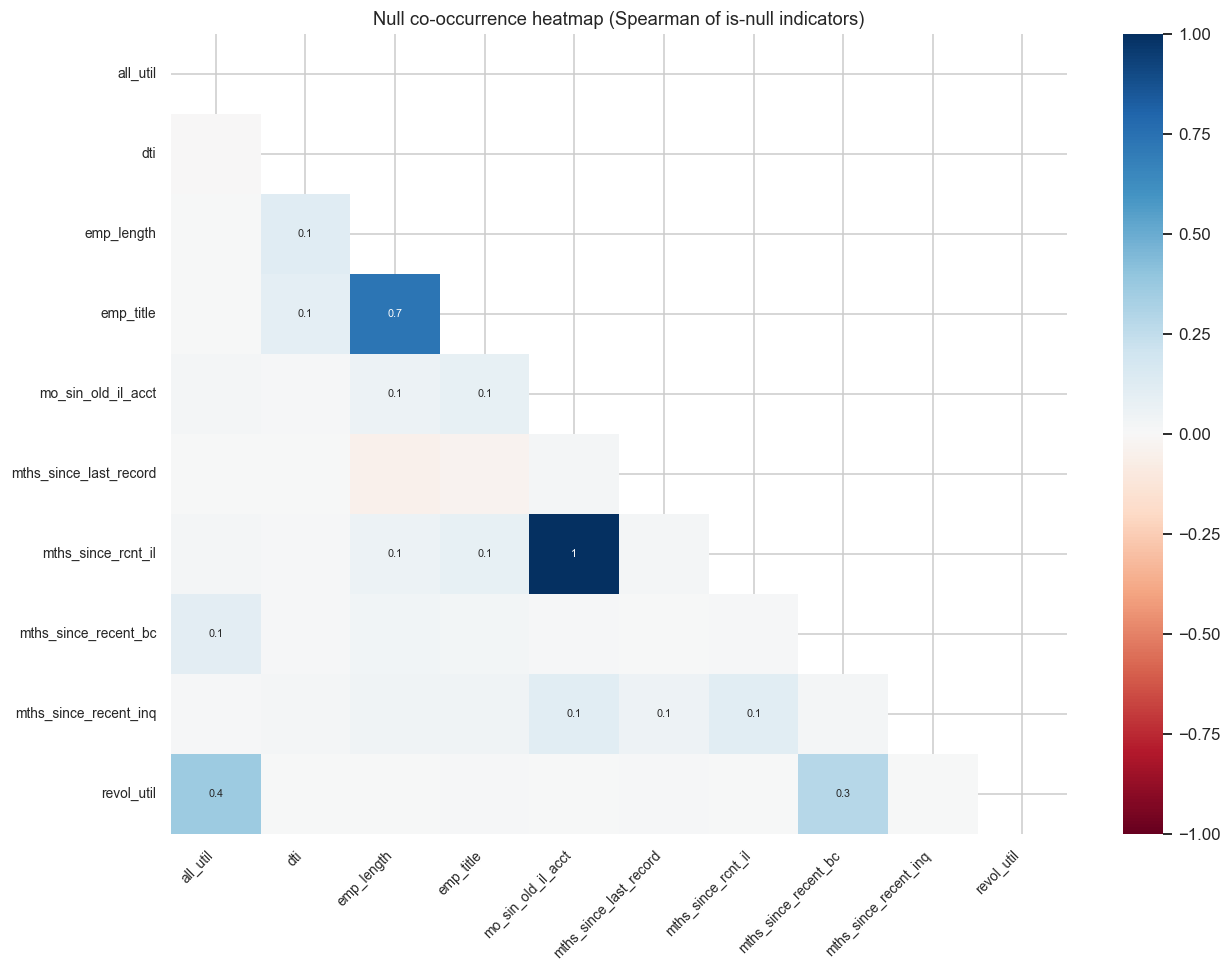

In [14]:
fig, ax = plt.subplots(figsize=(12, 9))
msno.heatmap(train, ax=ax, fontsize=9)
ax.set_title("Null co-occurrence heatmap (Spearman of is-null indicators)")
save_fig("03_missingness_cooccurrence")
plt.show()

In [15]:
# Point-biserial: does missingness in column X correlate with int_rate?
pb_rows = []
for col in null_table.index:
    is_null = train[col].isna().astype(int)
    if is_null.sum() < 50 or is_null.sum() > len(train) - 50:
        continue
    r, p = stats.pointbiserialr(is_null, train["int_rate"])
    pb_rows.append({"column": col, "pct_missing": null_table.loc[col, "pct"],
                    "pointbiserial_r": r, "p_value": p})
pb_df = pd.DataFrame(pb_rows)
pb_df["abs_r"] = pb_df["pointbiserial_r"].abs()
pb_df["flag_action"] = np.select(
    [
        (pb_df["pct_missing"] >= 5) & (pb_df["abs_r"] >= 0.02),
        (pb_df["pct_missing"] >= 1) & (pb_df["abs_r"] >= 0.02),
        (pb_df["pct_missing"] >= 5),
    ],
    [
        "add missingness flag",
        "consider flag; validate in CV",
        "usually impute only; weak target association",
    ],
    default="impute only; tiny missingness/effect",
)
pb_df = pb_df.sort_values(["abs_r", "pct_missing"], ascending=False)
print("Missingness indicator relationship with int_rate (effect-size first; p-values are secondary at n=100k):")
display(pb_df.head(15).round(4))

Missingness indicator relationship with int_rate (effect-size first; p-values are secondary at n=100k):


,column,pct_missing,pointbiserial_r,p_value,abs_r,flag_action
2,mths_since_recent_inq,9.98,-0.0743,0.0000,0.0743,add missingness flag
0,mths_since_last_record,90.88,-0.0365,0.0000,0.0365,add missingness flag
6,mths_since_recent_bc,0.92,0.0241,0.0000,0.0241,impute only; tiny missingness/effect
3,emp_length,8.67,0.0105,0.0009,0.0105,usually impute only; weak target association
7,dti,0.19,0.0071,0.0256,0.0071,impute only; tiny missingness/effect
8,revol_util,0.12,0.0069,0.0290,0.0069,impute only; tiny missingness/effect
4,mo_sin_old_il_acct,2.20,0.0056,0.0741,0.0056,impute only; tiny missingness/effect
5,mths_since_rcnt_il,2.20,0.0056,0.0741,0.0056,impute only; tiny missingness/effect
1,emp_title,14.92,0.0054,0.0902,0.0054,usually impute only; weak target association


**Missingness takeaway:** Use missingness flags only where missingness is both material and measurably associated with `int_rate`. In this slice, the strongest candidates are `mths_since_recent_inq` and `mths_since_last_record`; tiny-missingness fields like `dti` and `revol_util` should normally be imputed without extra flags.

## 4. Univariate distributions

Distribution shape for every numeric column, value counts for every categorical, plus a focused look at the `emp_length` and `term` text encodings.

In [16]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "int_rate"]
print(f"{len(numeric_cols)} numeric columns to plot")

skew_table = pd.DataFrame({
    "skew":      [train[c].skew() for c in numeric_cols],
    "n_unique":  [train[c].nunique() for c in numeric_cols],
    "n_zero":    [(train[c] == 0).sum() for c in numeric_cols],
    "pct_zero":  [(train[c] == 0).mean() * 100 for c in numeric_cols],
}, index=numeric_cols).round(3)
skew_table = skew_table.sort_values("skew", key=abs, ascending=False)
print("Skewness ranking (by |skew|):")
display(skew_table.head(20))

27 numeric columns to plot
Skewness ranking (by |skew|):


,skew,n_unique,n_zero,pct_zero
tot_coll_amt,86.771,3242,87541,87.541
annual_inc,35.978,9082,186,0.186
dti,22.286,6332,74,0.074
chargeoff_within_12_mths,21.528,6,99462,99.462
collections_12_mths_ex_med,13.727,6,98626,98.626
revol_bal,7.665,40332,712,0.712
delinq_2yrs,6.551,18,86002,86.002
mths_since_rcnt_il,4.430,261,37,0.037
mths_since_recent_bc,3.711,355,768,0.768
total_bal_ex_mort,3.324,68832,84,0.084


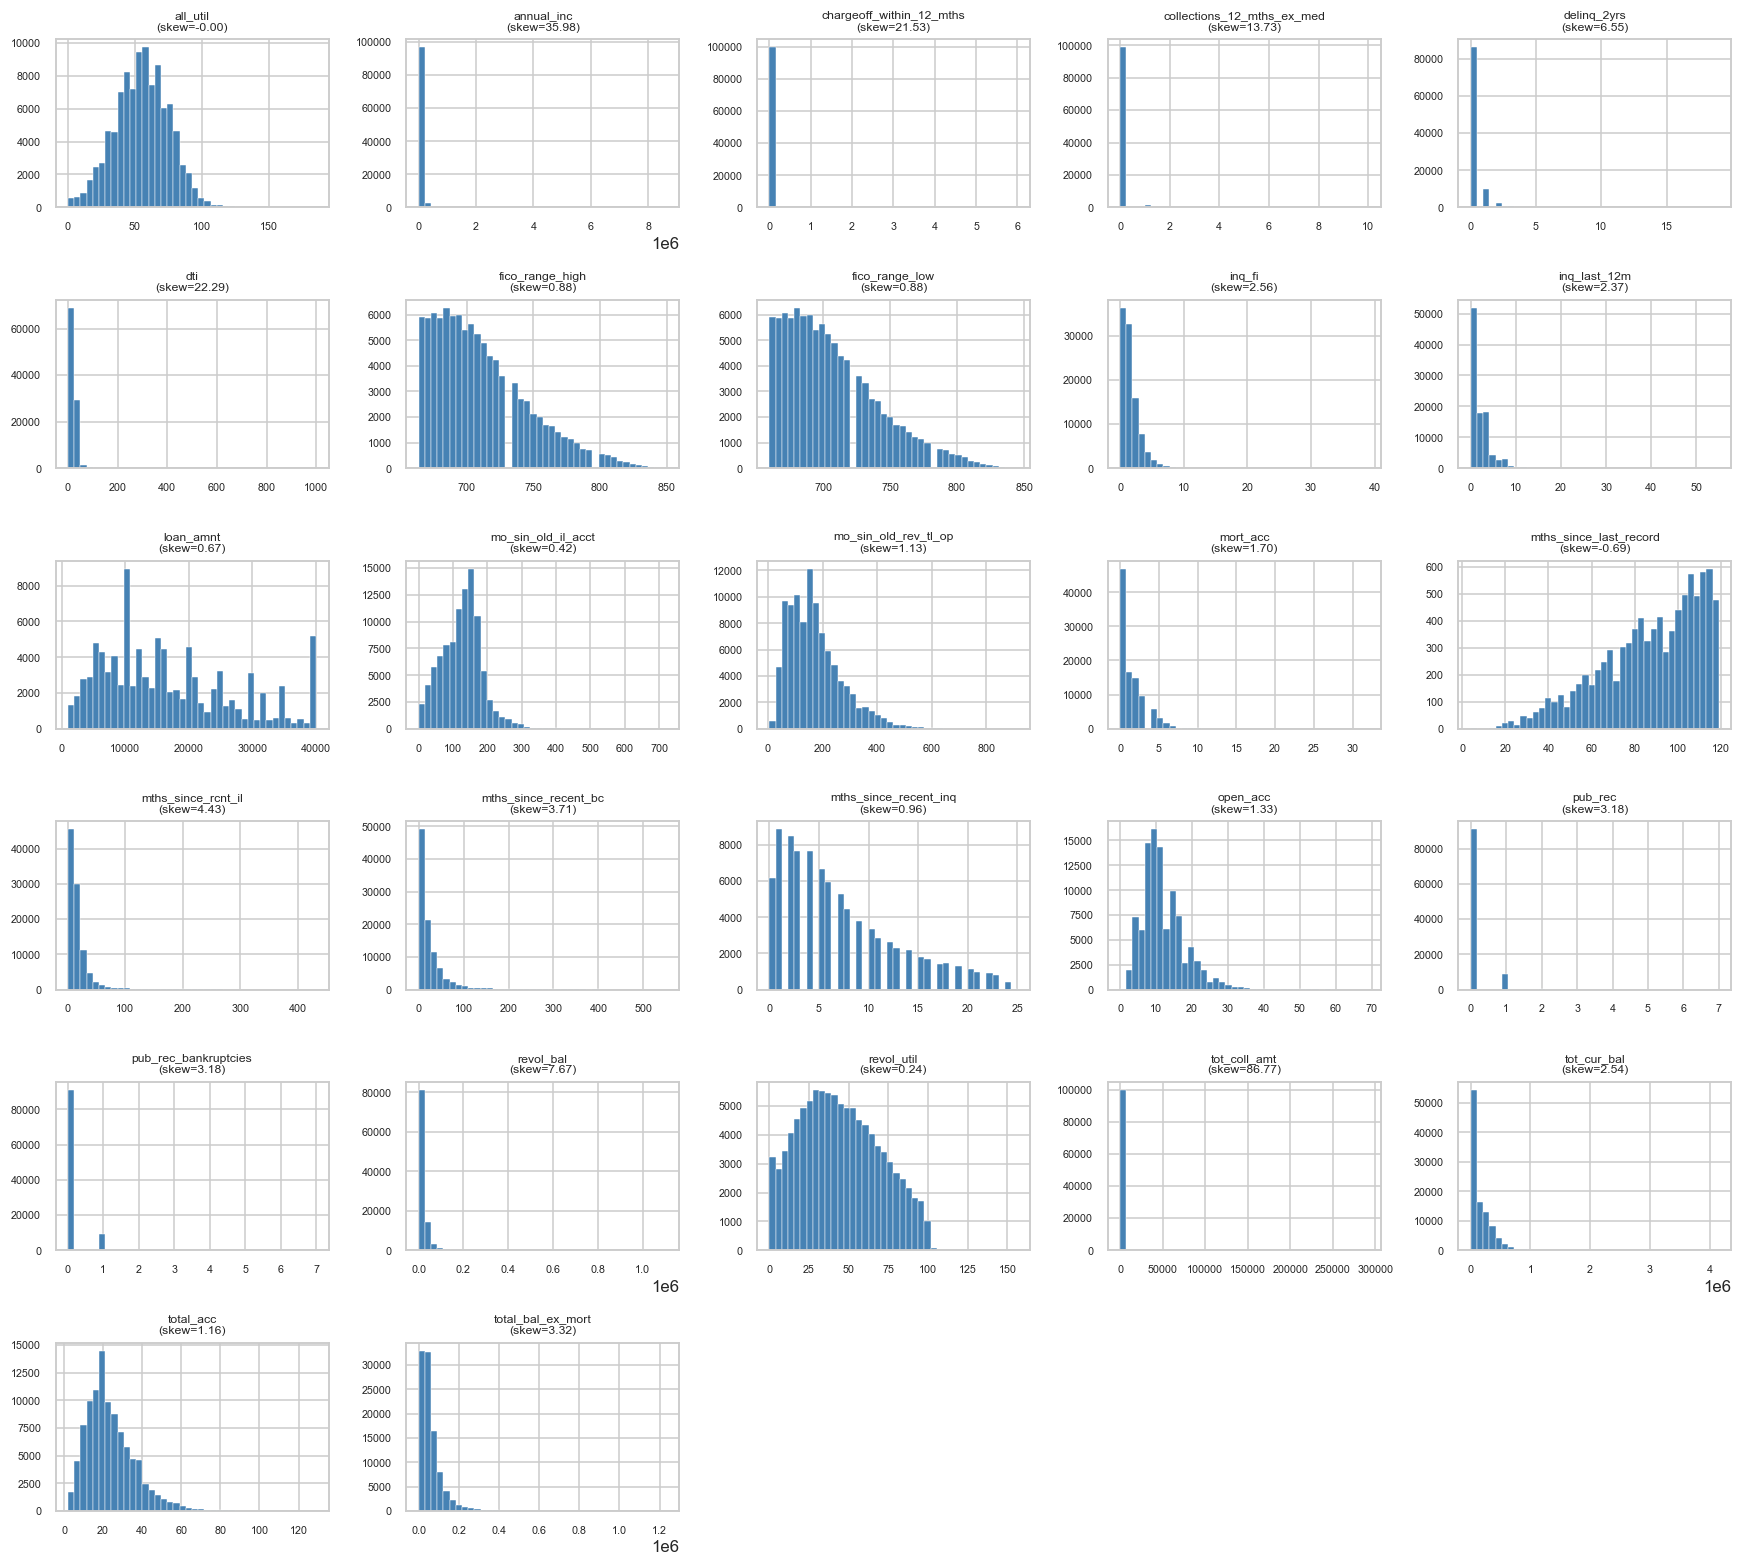

In [17]:
# Grid of numeric histograms — log scale where skew > 3 and positive
ncols = 5
nrows = int(np.ceil(len(numeric_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.4))
for i, col in enumerate(numeric_cols):
    ax = axes.flat[i]
    series = train[col].dropna()
    if len(series) == 0:
        ax.axis("off"); continue
    log_scale = abs(series.skew()) > 3 and (series > 0).all()
    if log_scale:
        ax.hist(np.log1p(series), bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
        ax.set_title(f"{col}\n(log1p, skew={series.skew():.1f})", fontsize=8)
    else:
        ax.hist(series, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
        ax.set_title(f"{col}\n(skew={series.skew():.2f})", fontsize=8)
    ax.tick_params(labelsize=7)
for j in range(len(numeric_cols), nrows * ncols):
    axes.flat[j].axis("off")
save_fig("04_numeric_histograms")
plt.show()

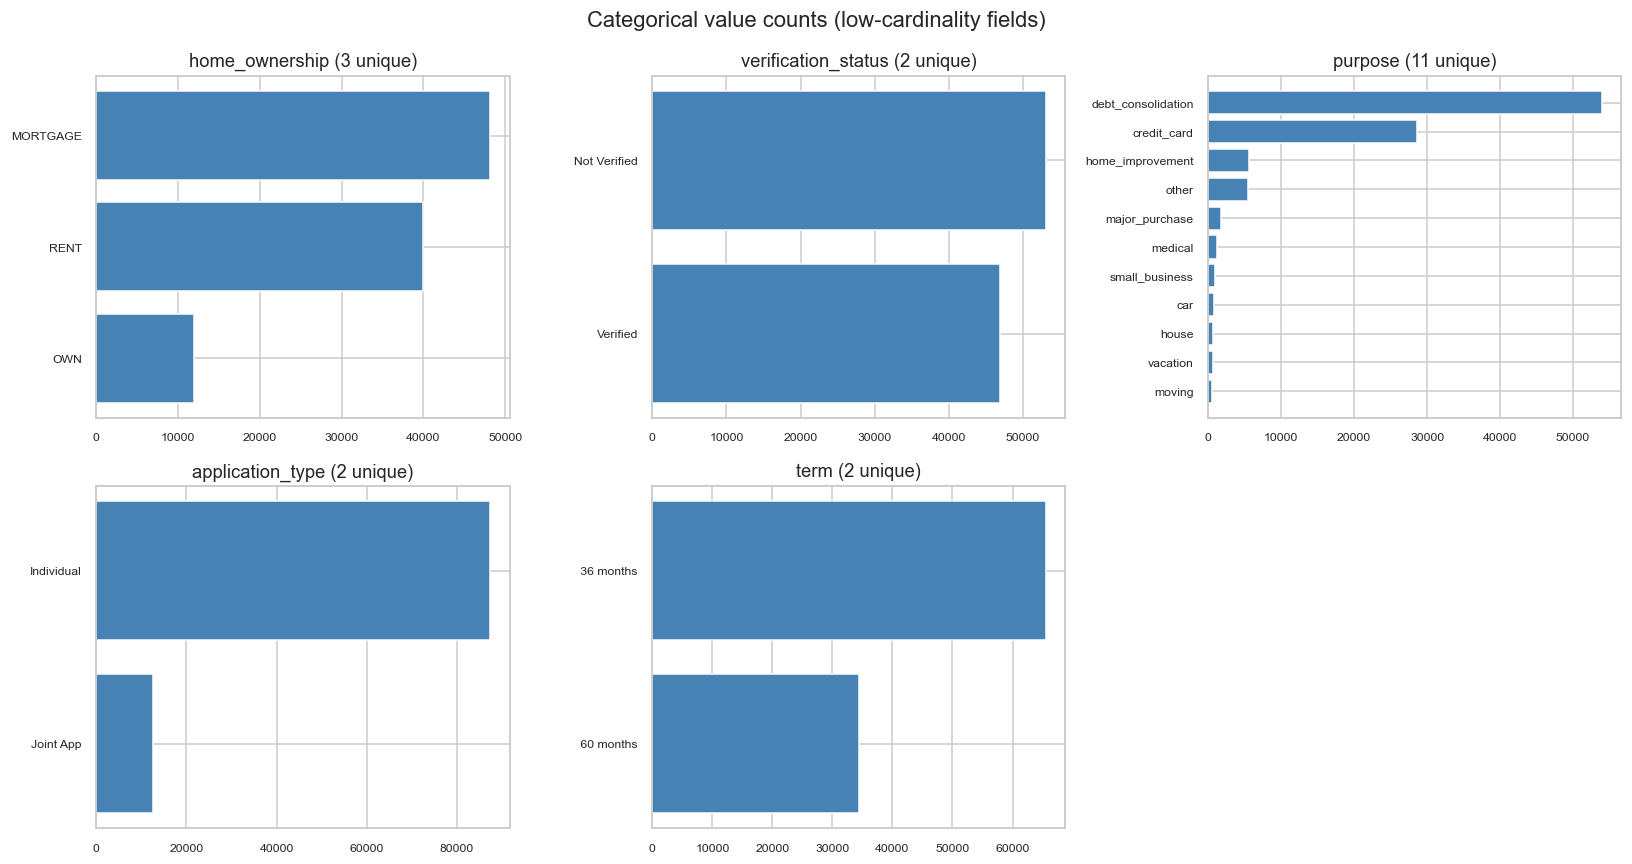

In [18]:
# Categorical value-count bars
cat_cols = [c for c in ["home_ownership", "verification_status", "purpose",
                        "application_type", "term"] if c in train.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cat_cols):
    vc = train[col].value_counts(dropna=False).head(15)
    ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color="steelblue")
    ax.set_title(f"{col} ({train[col].nunique(dropna=False)} unique)")
    ax.tick_params(labelsize=8)
for j in range(len(cat_cols), 6):
    axes.flat[j].axis("off")
plt.suptitle("Categorical value counts (low-cardinality fields)")
save_fig("04_categorical_counts")
plt.show()

In [19]:
# emp_length raw values + ordinal mapping proposal
emp_vc = train["emp_length"].value_counts(dropna=False)
print("emp_length raw value counts:")
print(emp_vc.to_string())
print("\nProposed ordinal mapping (mirrors src/archive/preprocessing_and_modeling.py):")
for k, v in EMP_LENGTH_MAP.items():
    print(f"  {k:<12s} -> {v}")

emp_length raw value counts:
emp_length
10+ years    28343
< 1 year     13331
2 years       9116
NaN           8669
3 years       7904
1 year        6913
5 years       6565
4 years       5915
6 years       4332
7 years       3519
8 years       3133
9 years       2260

Proposed ordinal mapping (mirrors src/archive/preprocessing_and_modeling.py):
  < 1 year     -> 0
  1 year       -> 1
  2 years      -> 2
  3 years      -> 3
  4 years      -> 4
  5 years      -> 5
  6 years      -> 6
  7 years      -> 7
  8 years      -> 8
  9 years      -> 9
  10+ years    -> 10
  n/a          -> None


## 5. FICO score analysis

The prior `data/` slice had no FICO columns — they were stripped under TransUnion licensing. This `true data/` slice has both `fico_range_low` and `fico_range_high`. FICO is the canonical credit-quality signal in consumer lending; expect it to be the strongest non-leakage predictor.

(This section replaces the temporal analysis from the prior notebook — there is no `issue_d` here, so temporal validation is impossible. **The validation strategy must be a random split** on this dataset, with the caveat that out-of-time generalization cannot be measured.)

In [20]:
# fico_range_high - fico_range_low is almost always 4 in this slice
# (14 rows are 5), so the two columns carry the same information.
fico_diff = (train["fico_range_high"] - train["fico_range_low"]).unique()
print(f"Unique values of (fico_range_high - fico_range_low): {sorted(fico_diff.tolist())}")
print()
# Add diagnostic derived fields to the safe application-time frames only.
train["fico"] = (train["fico_range_low"] + train["fico_range_high"]) / 2.0
test["fico"]  = (test["fico_range_low"]  + test["fico_range_high"])  / 2.0
train["term_months"] = train["term"].astype(str).str.extract(r"(36|60)", expand=False).astype("int16")
test["term_months"]  = test["term"].astype(str).str.extract(r"(36|60)", expand=False).astype("int16")
train["zip3"] = train["zip_code"].astype(str).str[:3]
test["zip3"]  = test["zip_code"].astype(str).str[:3]
train["zip_first_digit"] = train["zip_code"].astype(str).str[0]
test["zip_first_digit"]  = test["zip_code"].astype(str).str[0]
print(f"FICO range: {train['fico'].min():.0f} - {train['fico'].max():.0f}")
print(f"FICO mean:  {train['fico'].mean():.1f}, median: {train['fico'].median():.0f}, std: {train['fico'].std():.1f}")
print("Derived fields added: fico, term_months, zip3, zip_first_digit")

Unique values of (fico_range_high - fico_range_low): [4, 5]

FICO range: 662 - 848
FICO mean:  708.6, median: 702, std: 35.6
Derived fields added: fico, term_months, zip3, zip_first_digit


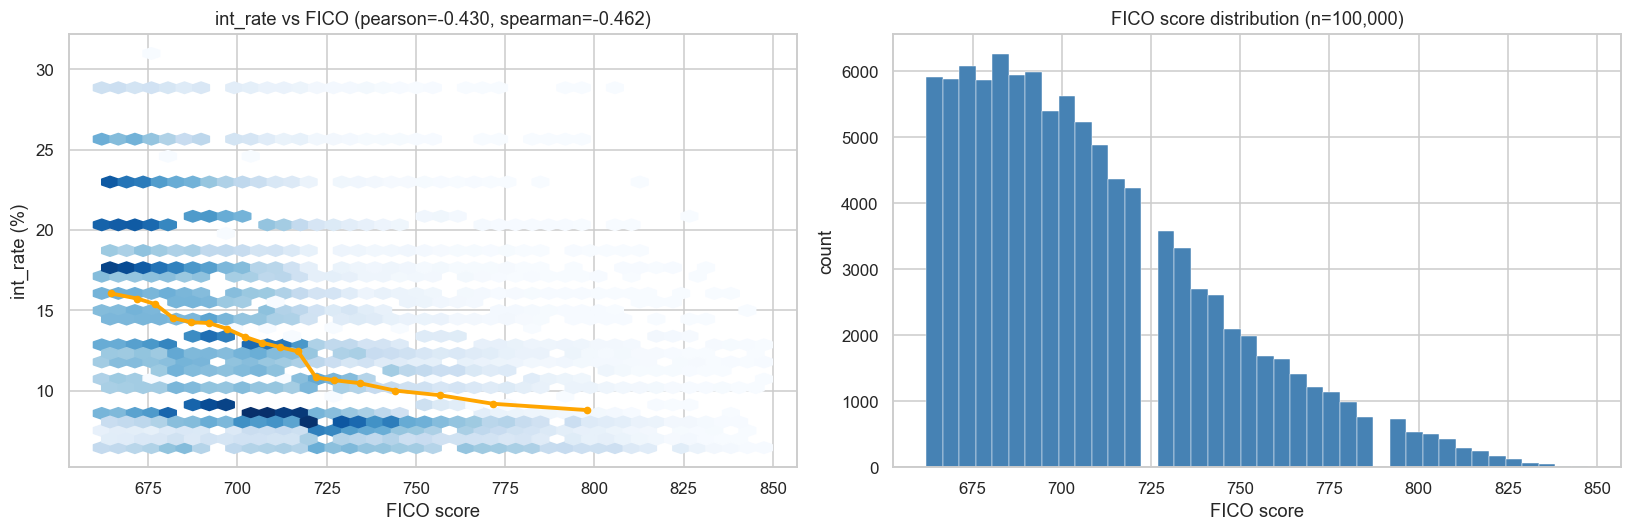


FICO is the dominant non-leakage signal: pearson r = -0.4297


In [21]:
# FICO vs int_rate — the headline relationship
sub = train[["fico", "int_rate"]].dropna()
pr, _ = stats.pearsonr(sub["fico"], sub["int_rate"])
sr, _ = stats.spearmanr(sub["fico"], sub["int_rate"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hexbin scatter
axes[0].hexbin(sub["fico"], sub["int_rate"], gridsize=40, cmap="Blues", mincnt=1)
# Binned mean overlay
bins = pd.qcut(sub["fico"], q=20, duplicates="drop")
binned = sub.groupby(bins, observed=True).agg({"fico": "mean", "int_rate": "mean"})
axes[0].plot(binned["fico"], binned["int_rate"], color="orange", linewidth=2.5, marker="o", markersize=4)
axes[0].set_xlabel("FICO score")
axes[0].set_ylabel("int_rate (%)")
axes[0].set_title(f"int_rate vs FICO (pearson={pr:+.3f}, spearman={sr:+.3f})")

# FICO distribution
axes[1].hist(train["fico"].dropna(), bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("FICO score")
axes[1].set_ylabel("count")
axes[1].set_title(f"FICO score distribution (n={train['fico'].notna().sum():,})")

save_fig("05_fico_analysis")
plt.show()
print(f"\nFICO is the dominant non-leakage signal: pearson r = {pr:.4f}")

**FICO takeaway:** `fico_range_low` and `fico_range_high` are effectively duplicate boundaries, so the midpoint `fico` is the clean modeling representation. Keep the midpoint and drop the raw pair before modeling to avoid duplicated attribution.

## 6. Bivariate analysis vs target

Spearman correlation handles the skew in monetary columns better than Pearson. The categorical boxplots and the `addr_state` bar chart probe what each non-numeric column buys you.

In [22]:
# Pearson + Spearman ranking. Use the FICO midpoint to avoid triple-counting
# fico_range_low, fico_range_high, and fico as three copies of the same signal.
CORR_EXCLUDE = {"int_rate", "ID", "fico_range_low", "fico_range_high"}
features_for_corr = [c for c in numeric_cols if c not in CORR_EXCLUDE]
# Add the derived FICO midpoint we computed in §5.
features_for_corr = list(dict.fromkeys(features_for_corr + ["fico"]))
assert "loan_status" not in features_for_corr

rows = []
for c in features_for_corr:
    valid = train[[c, "int_rate"]].dropna()
    if len(valid) < 100:
        continue
    pr, _ = stats.pearsonr(valid[c], valid["int_rate"])
    sr, _ = stats.spearmanr(valid[c], valid["int_rate"])
    rows.append({"feature": c, "pearson": pr, "spearman": sr, "n": len(valid)})
corr_df = pd.DataFrame(rows).set_index("feature")
corr_df["abs_spearman"] = corr_df["spearman"].abs()
corr_df = corr_df.sort_values("abs_spearman", ascending=False)
print("Top 15 features by |Spearman| with int_rate:")
display(corr_df.head(15).round(4))

Top 15 features by |Spearman| with int_rate:


,pearson,spearman,n,abs_spearman
feature,,,,
fico,-0.4297,-0.4620,100000,0.4620
all_util,0.3164,0.3338,99984,0.3338
revol_util,0.2896,0.2998,99877,0.2998
dti,0.0979,0.1787,99814,0.1787
mo_sin_old_rev_tl_op,-0.1197,-0.1397,100000,0.1397
inq_fi,0.1240,0.1245,100000,0.1245
mths_since_rcnt_il,-0.0735,-0.1240,97796,0.1240
inq_last_12m,0.1064,0.1163,100000,0.1163
mort_acc,-0.1020,-0.1087,100000,0.1087


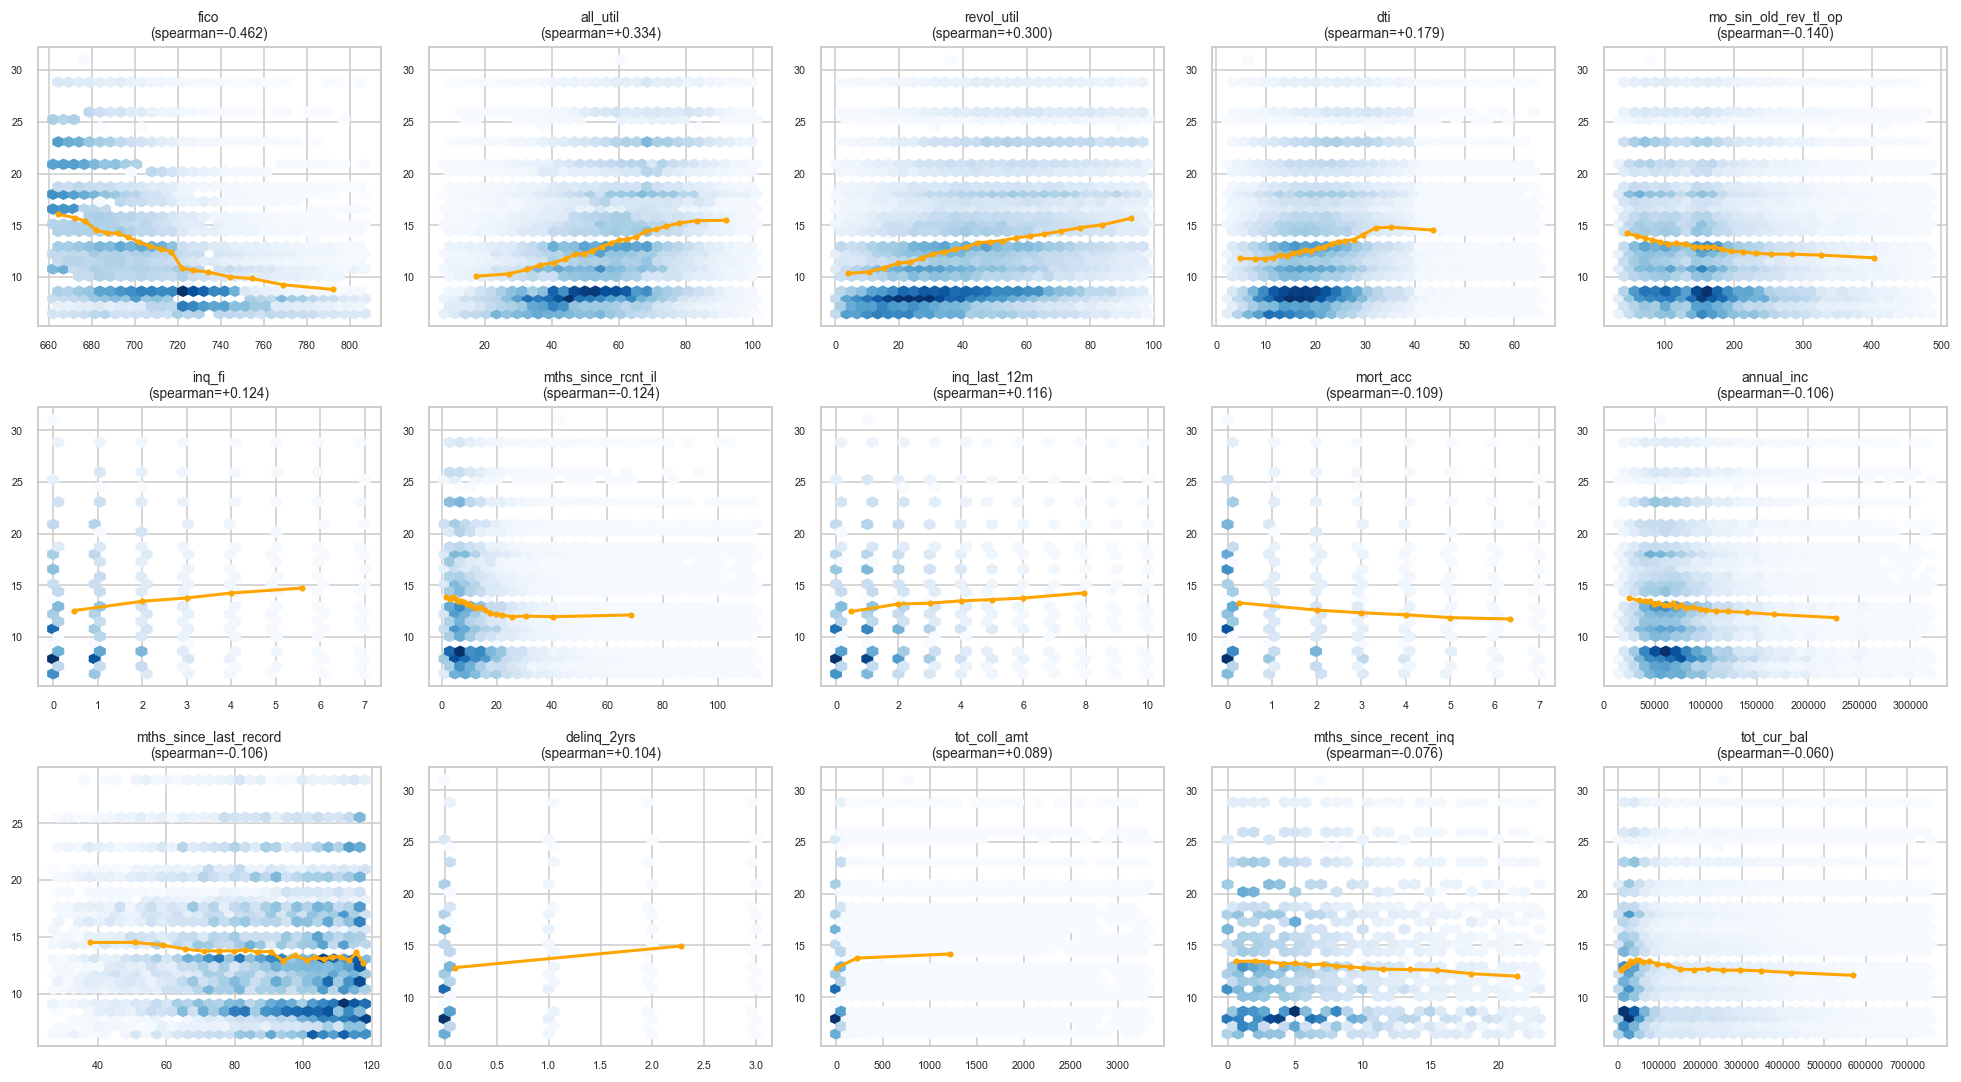

In [23]:
# Hexbin grid for top-15 most-correlated numerics
top15_feats = corr_df.head(15).index.tolist()
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, col in zip(axes.flat, top15_feats):
    sub = train[[col, "int_rate"]].dropna()
    if len(sub) < 100:
        ax.axis("off"); continue
    lo, hi = sub[col].quantile([0.01, 0.99])
    sub = sub[(sub[col] >= lo) & (sub[col] <= hi)]
    ax.hexbin(sub[col], sub["int_rate"], gridsize=30, cmap="Blues", mincnt=1)
    try:
        bins = pd.qcut(sub[col], q=20, duplicates="drop")
        binned = sub.groupby(bins, observed=True).agg({col: "mean", "int_rate": "mean"})
        ax.plot(binned[col], binned["int_rate"], color="orange", linewidth=2, marker="o", markersize=3)
    except ValueError:
        pass
    sp = corr_df.loc[col, "spearman"]
    ax.set_title(f"{col}\n(spearman={sp:+.3f})", fontsize=9)
    ax.tick_params(labelsize=7)
save_fig("06_bivariate_hexbin")
plt.show()

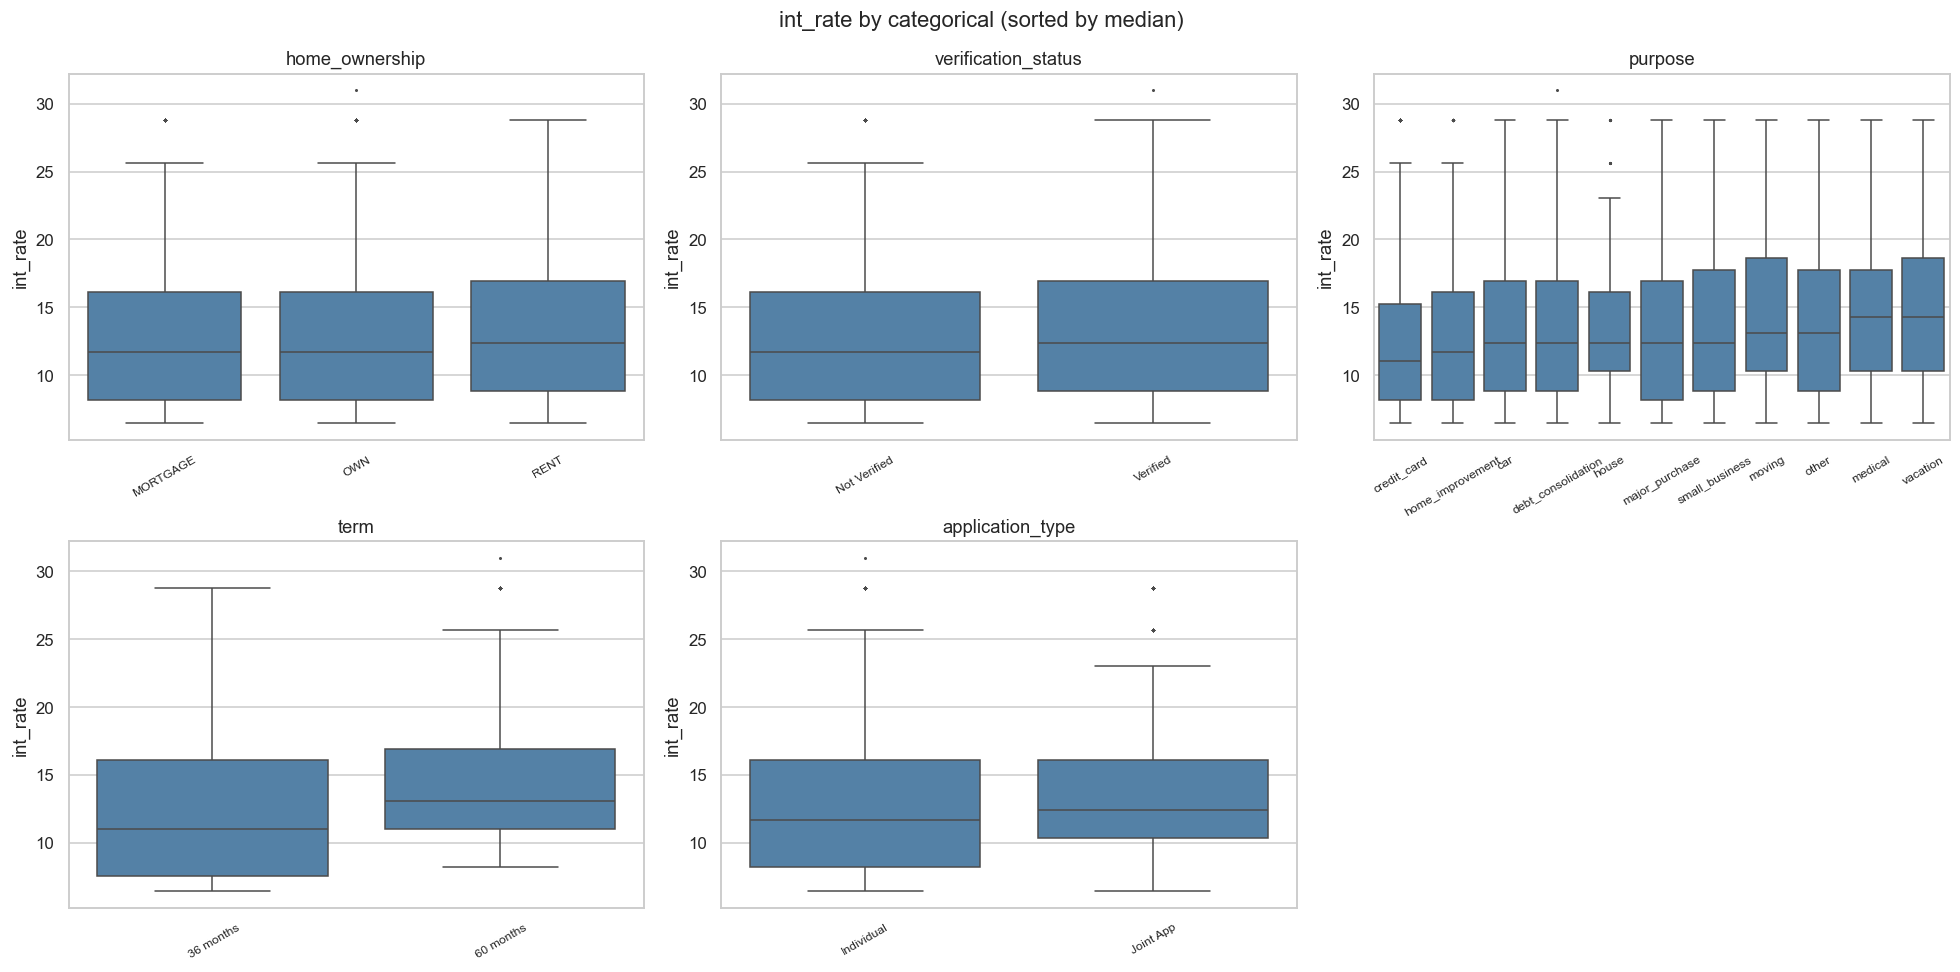

In [24]:
# Categorical boxplots vs target
cat_for_box = [c for c in ["home_ownership", "verification_status", "purpose",
                           "term", "application_type"] if c in train.columns]
n = len(cat_for_box)
rows = int(np.ceil(n / 3))
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4.5))
for ax, col in zip(axes.flat, cat_for_box):
    order = train.groupby(col)["int_rate"].median().sort_values().index
    sns.boxplot(data=train, x=col, y="int_rate", order=order, ax=ax,
                color="steelblue", fliersize=1)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.set_xlabel("")
for j in range(n, rows * 3):
    axes.flat[j].axis("off")
plt.suptitle("int_rate by categorical (sorted by median)")
save_fig("06_categorical_boxplots")
plt.show()

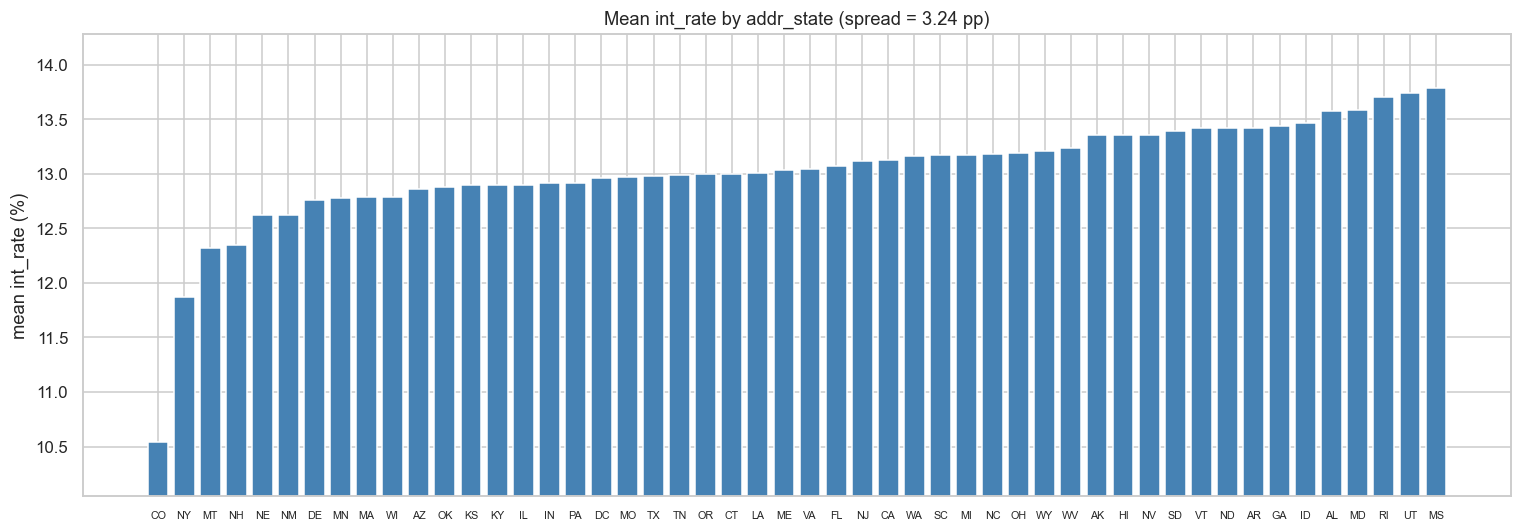

In [25]:
# addr_state sorted bar with sample-size annotations
state_stats = train.groupby("addr_state")["int_rate"].agg(["mean", "count"]).sort_values("mean")
spread = state_stats['mean'].max() - state_stats['mean'].min()
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(state_stats.index, state_stats["mean"], color="steelblue")
ax.set_title(f"Mean int_rate by addr_state (spread = {spread:.2f} pp)")
ax.set_ylabel("mean int_rate (%)")
ax.tick_params(axis="x", labelsize=7)
ax.set_ylim(state_stats["mean"].min() - 0.5, state_stats["mean"].max() + 0.5)
save_fig("06_state_bar")
plt.show()

**Bivariate takeaway:** Once FICO is represented once, the next strongest raw numeric signals are utilization and debt-burden fields. Treat state and term as useful categorical structure, but validate their incremental value in the modeling pipeline.

## 7. Correlation & multicollinearity

Pairwise feature correlations expose redundancy clusters. Pairs with |r|>0.85 are candidates for dropping the less interpretable member; XGBoost is robust to multicollinearity for predictive accuracy, but SHAP attributions split across correlated features.

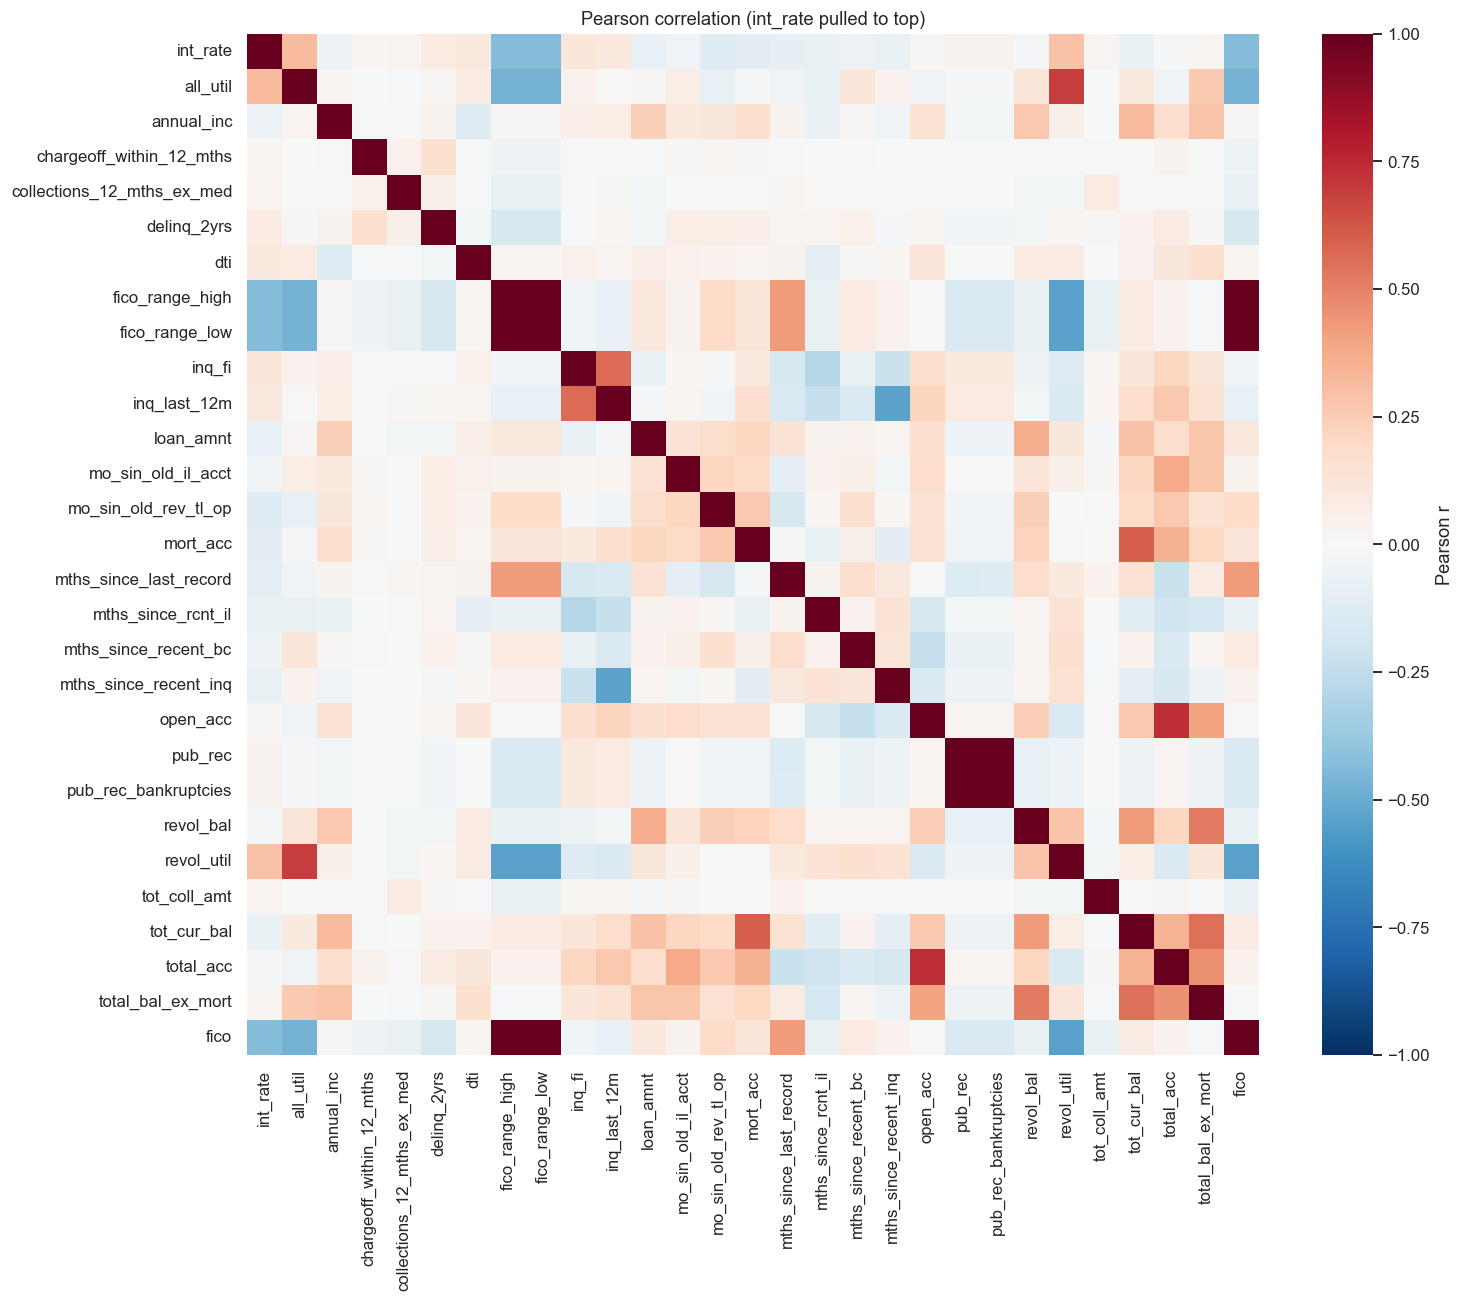

In [26]:
corr_cols = [c for c in numeric_cols if c not in {"ID"}] + ["fico"]
corr_cols = list(dict.fromkeys(corr_cols))
corr_mat = train[corr_cols + ["int_rate"]].corr()
order = ["int_rate"] + [c for c in corr_mat.columns if c != "int_rate"]
corr_mat = corr_mat.loc[order, order]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_mat, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=False, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Pearson correlation (int_rate pulled to top)")
save_fig("07_correlation_heatmap")
plt.show()

In [27]:
# High-correlation pairs (|r|>0.7) excluding self-pairs and int_rate
pair_corr = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool)).stack()
pair_corr = pair_corr[pair_corr.abs() > 0.7]
pair_corr = pair_corr.sort_values(key=abs, ascending=False)
pair_df = pair_corr.reset_index()
pair_df.columns = ["feature_a", "feature_b", "pearson_r"]
pair_df = pair_df[~pair_df.apply(lambda r: r["feature_a"] == "int_rate" or r["feature_b"] == "int_rate", axis=1)]
print(f"Numeric pairs with |Pearson r| > 0.7: {len(pair_df)}")
display(pair_df.round(4))

Numeric pairs with |Pearson r| > 0.7: 5


,feature_a,feature_b,pearson_r
0,fico_range_high,fico,1.0000
1,fico_range_low,fico,1.0000
2,fico_range_high,fico_range_low,1.0000
3,pub_rec,pub_rec_bankruptcies,0.9995
4,open_acc,total_acc,0.7372


## 8. Leakage audit

This dataset's leakage story is different from the prior `data/` slice:

- **`grade`, `sub_grade`, `installment`** — **ABSENT**. The classic pre-origination leakage trio doesn't exist here.
- **`loan_status`** — **PRESENT** and **already dropped** at the top of the notebook. It is the current status of the loan (Current, Fully Paid, Charged Off, In Grace Period, Late, Issued), which is not available as an application-time borrower feature. We quantify its association here using the side copy `loan_status_audit` saved before the drop, then discard the copy.

The exclusion is an availability-timing decision, not a claim that `loan_status` is the strongest predictor. Its observed association with `int_rate` is small but invalid for application-time modeling.

In [28]:
# Compute the leakage using the side copy preserved before the drop
ls_audit = loan_status_audit.copy()
status_means = ls_audit.groupby("loan_status")["int_rate"].agg(["mean", "median", "std", "count"]).sort_values("mean")
print("Mean int_rate by loan_status:")
display(status_means.round(3))
print()
print(f"loan_status mean-rate spread (max − min): "
      f"{status_means['mean'].max() - status_means['mean'].min():.2f} pp")

Mean int_rate by loan_status:


,mean,median,std,count
loan_status,,,,
Current,12.879,11.71,5.218,95779
Issued,13.769,13.08,5.329,518
Fully Paid,14.251,13.08,5.879,2738
Charged Off,14.392,13.08,5.670,39
In Grace Period,14.821,14.30,5.706,483
Late,16.298,16.12,5.954,443



loan_status mean-rate spread (max − min): 3.42 pp


In [29]:
# Effect size: one-way ANOVA F-statistic
groups = [g["int_rate"].dropna().values for _, g in ls_audit.groupby("loan_status")]
groups = [g for g in groups if len(g) > 1]
F, p = stats.f_oneway(*groups)

# Eta squared: proportion of int_rate variance explained by loan_status
grand_mean = ls_audit["int_rate"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((ls_audit["int_rate"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

print(f"One-way ANOVA F({len(groups)-1}, {sum(len(g)-1 for g in groups)}) = {F:.2f}")
print(f"p-value: {p:.3e}")
print(f"Eta-squared (variance explained by loan_status): {eta_sq:.4f}")
print()
print(f"→ loan_status explains {eta_sq*100:.2f}% of int_rate variance.")
print("  The effect is modest; the exclusion is because status is unavailable at application time.")

One-way ANOVA F(5, 99994) = 88.69
p-value: 2.064e-93
Eta-squared (variance explained by loan_status): 0.0044

→ loan_status explains 0.44% of int_rate variance.
  The effect is modest; the exclusion is because status is unavailable at application time.


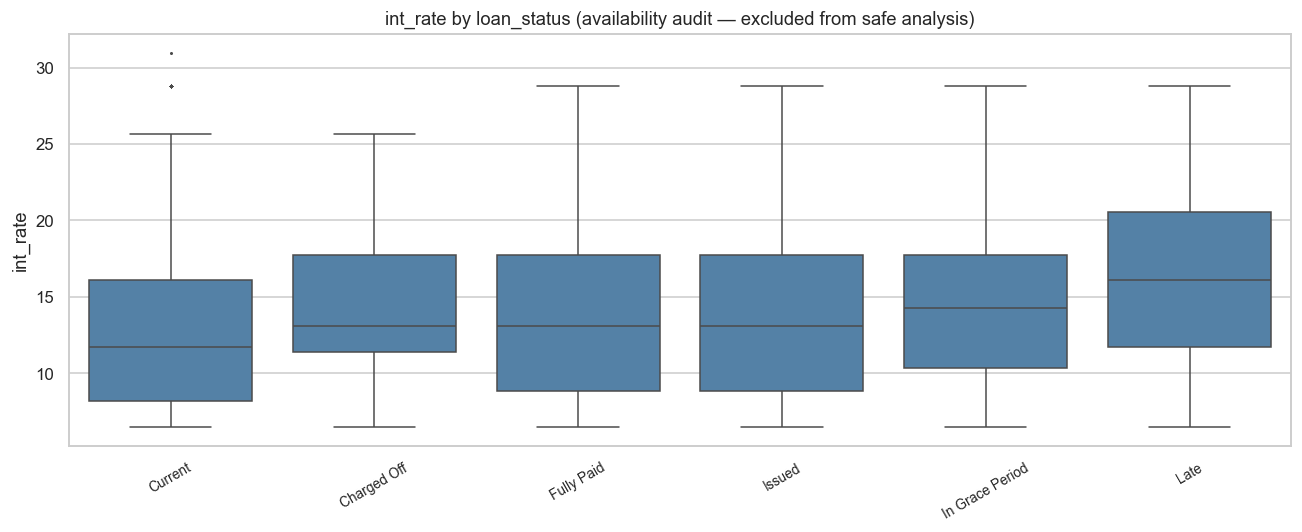

In [30]:
# Visualize separation
fig, ax = plt.subplots(figsize=(12, 5))
order = ls_audit.groupby("loan_status")["int_rate"].median().sort_values().index
sns.boxplot(data=ls_audit, x="loan_status", y="int_rate", order=order,
            ax=ax, color="steelblue", fliersize=1)
ax.set_title("int_rate by loan_status (availability audit — excluded from safe analysis)")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.set_xlabel("")
save_fig("08_loan_status_leakage")
plt.show()

In [31]:
# Discard the audit copy — leakage column never re-enters working dataframes
del loan_status_audit, ls_audit
print("loan_status audit copy discarded.")
print()
print("LEAKAGE_COLS_POST_ORIGINATION =", LEAKAGE_COLS_POST_ORIGINATION)
print("(grade, sub_grade, installment from the prior dataset are NOT present here.)")

loan_status audit copy discarded.

LEAKAGE_COLS_POST_ORIGINATION = ['loan_status']
(grade, sub_grade, installment from the prior dataset are NOT present here.)


## 9. Cardinality analysis

High-cardinality string columns need an explicit encoding strategy. `emp_title` is free text; `title` is a one-to-one human-readable duplicate of `purpose` in this slice; `zip_code` is a masked 3-digit prefix; `addr_state` is ~50 levels.

In [32]:
card_rows = []
exclude = {"int_rate"}
for c in train.columns:
    if c in exclude:
        continue
    nunique = train[c].nunique(dropna=True)
    n_missing = train[c].isna().sum()
    top = train[c].value_counts(dropna=True).head(3)
    top_str = ", ".join(f"{repr(v)[:20]}:{n}" for v, n in top.items())
    card_rows.append({
        "column": c,
        "dtype": str(train[c].dtype),
        "n_unique": nunique,
        "pct_missing": round(n_missing / len(train) * 100, 2),
        "top_3": top_str[:80],
    })
card_df = pd.DataFrame(card_rows).sort_values("n_unique", ascending=False)
print("Cardinality table (sorted by n_unique):")
display(card_df.head(20))

Cardinality table (sorted by n_unique):


,column,dtype,n_unique,pct_missing,top_3
32,tot_cur_bal,float64,83628,0.00,"0.0:55, 34987.0:7, 23714.0:7"
34,total_bal_ex_mort,int64,68832,0.00,"0:84, 33110:8, 34987:8"
27,revol_bal,int64,40332,0.00,"0:712, 8:16, 9835:13"
9,emp_title,str,35337,14.92,"'Teacher':1604, 'Manager':1408, 'Driver':788"
2,annual_inc,float64,9082,0.00,"60000.0:3648, 50000.0:2948, 80000.0:2804"
7,dti,float64,6332,0.19,"0.0:74, 19.04:71, 18.6:70"
31,tot_coll_amt,int64,3242,0.00,"0:87541, 50:121, 100:90"
15,loan_amnt,int64,1534,0.00,"10000:5687, 40000:5053, 15000:4124"
28,revol_util,float64,1072,0.12,"0.0:756, 25.8:175, 32.7:174"
39,zip3,str,873,0.00,"'750':998, '945':994, '112':974"


In [33]:
title_purpose_pairs = (
    train.groupby(["purpose", "title"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["purpose", "title"])
)
n_titles_per_purpose = title_purpose_pairs.groupby("purpose")["title"].nunique(dropna=False)
n_purposes_per_title = title_purpose_pairs.groupby("title")["purpose"].nunique(dropna=False)

print(f"Observed purpose/title pairs: {len(title_purpose_pairs)}")
print(f"purpose unique values: {train['purpose'].nunique(dropna=False)}")
print(f"title unique values:   {train['title'].nunique(dropna=False)}")
print(f"max titles per purpose: {n_titles_per_purpose.max()}")
print(f"max purposes per title: {n_purposes_per_title.max()}")
assert len(title_purpose_pairs) == train["purpose"].nunique(dropna=False) == train["title"].nunique(dropna=False)
assert n_titles_per_purpose.max() == 1 and n_purposes_per_title.max() == 1
display(title_purpose_pairs)

Observed purpose/title pairs: 11
purpose unique values: 11
title unique values:   11
max titles per purpose: 1
max purposes per title: 1


,purpose,title,n
0,car,Car financing,765
1,credit_card,Credit card refinancing,28632
2,debt_consolidation,Debt consolidation,53936
3,home_improvement,Home improvement,5609
4,house,Home buying,676
5,major_purchase,Major purchase,1759
6,medical,Medical expenses,1159
7,moving,Moving and relocation,531
8,other,Other,5427
9,small_business,Business,878


In [34]:
recommendations = pd.DataFrame([
    ["emp_title",   "35k unique free text",    "DROP or hash — no clean grouping"],
    ["title",       "11 labels",               "DROP — one-to-one duplicate of purpose"],
    ["zip_code",    "masked 3-digit prefix",   "Optional — usually flat signal"],
    ["addr_state",  "~50 US states",           "KEEP — native XGBoost categorical"],
    ["purpose",     "11 levels",               "KEEP — native categorical"],
    ["emp_length",  "11 ordinal-like levels",  "ENCODE via EMP_LENGTH_MAP"],
    ["home_ownership",      "3 levels",        "KEEP — native categorical"],
    ["verification_status", "2 levels",        "KEEP — native categorical"],
    ["term",                "2 levels",        "EXTRACT integer months"],
    ["application_type",    "2 levels (87/13 split)", "KEEP or validate; not constant"],
], columns=["column", "cardinality", "recommendation"])
display(recommendations)

,column,cardinality,recommendation
0,emp_title,35k unique free text,DROP or hash — no clean grouping
1,title,11 labels,DROP — one-to-one duplicate of purpose
2,zip_code,masked 3-digit prefix,Optional — usually flat signal
3,addr_state,~50 US states,KEEP — native XGBoost categorical
4,purpose,11 levels,KEEP — native categorical
5,emp_length,11 ordinal-like levels,ENCODE via EMP_LENGTH_MAP
6,home_ownership,3 levels,KEEP — native categorical
7,verification_status,2 levels,KEEP — native categorical
8,term,2 levels,EXTRACT integer months
9,application_type,2 levels (87/13 split),KEEP or validate; not constant


**Cardinality takeaway:** `title` is not merely semantically similar to `purpose`; it is an exact 11-pair one-to-one recoding in this train slice. Drop `title`, keep `purpose`, and avoid spending model capacity on `emp_title` unless a later text-specific experiment proves value.

## 10. Train vs test distribution parity (drift check)

Without `issue_d` we cannot say whether train→test drift is temporal. We still quantify it: Kolmogorov–Smirnov per numeric, Population Stability Index (PSI, 10-bin), chi-square per categorical. Strong drift on a non-temporal split usually means the test split was sampled differently (different sampling weights, different rejection-inference treatment, etc.).

In [35]:
def psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    if len(expected) < 50 or len(actual) < 50:
        return np.nan
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return np.nan
    edges[0], edges[-1] = -np.inf, np.inf
    e_pct = pd.cut(expected, edges).value_counts(normalize=True).sort_index()
    a_pct = pd.cut(actual, edges).value_counts(normalize=True).sort_index()
    eps = 1e-6
    return float(((a_pct - e_pct) * np.log((a_pct + eps) / (e_pct + eps))).sum())

drift_rows = []
shared_numeric = [c for c in numeric_cols if c in test.columns and c != "ID"]
assert "loan_status" not in shared_numeric
for c in shared_numeric:
    a, b = train[c].dropna(), test[c].dropna()
    if len(a) < 50 or len(b) < 50:
        continue
    ks_stat, ks_p = stats.ks_2samp(a, b)
    drift_rows.append({
        "feature": c,
        "ks_D": ks_stat,
        "ks_p": ks_p,
        "psi": psi(a, b),
        "train_mean": a.mean(),
        "test_mean":  b.mean(),
        "delta_mean": b.mean() - a.mean(),
    })
drift_df = pd.DataFrame(drift_rows).set_index("feature").sort_values("ks_D", ascending=False)
print("Numeric drift between train and test (sorted by KS D-statistic):")
display(drift_df.round(4).head(20))
print()
print("PSI interpretation: <0.1 = stable, 0.1-0.2 = monitor, >0.2 = significant shift")

Numeric drift between train and test (sorted by KS D-statistic):


,ks_D,ks_p,psi,train_mean,test_mean,delta_mean
feature,,,,,,
loan_amnt,0.1419,0.0000,0.1688,16833.1722,13793.9675,-3039.2047
mths_since_recent_bc,0.1399,0.0000,0.1164,24.4708,28.4443,3.9735
mths_since_rcnt_il,0.0780,0.0000,0.0724,17.3343,16.0592,-1.2752
fico_range_high,0.0694,0.0000,0.0259,710.6082,716.1268,5.5186
fico_range_low,0.0694,0.0000,0.0259,706.6081,712.1265,5.5184
total_acc,0.0544,0.0000,0.0199,23.8651,25.2964,1.4313
revol_bal,0.0490,0.0000,0.0107,19093.2482,17257.1289,-1836.1193
mths_since_recent_inq,0.0482,0.0000,0.0198,7.0073,7.4525,0.4452
all_util,0.0481,0.0000,0.0198,55.1069,52.7380,-2.3689



PSI interpretation: <0.1 = stable, 0.1-0.2 = monitor, >0.2 = significant shift


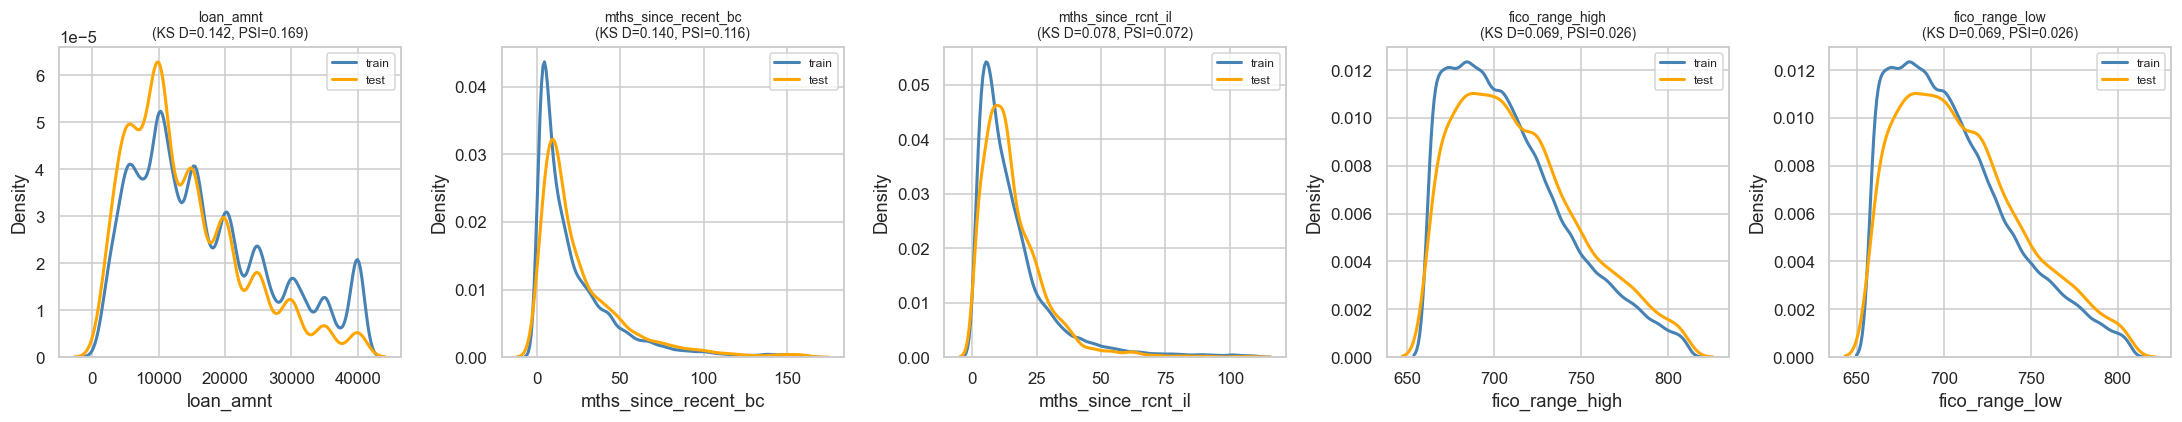

In [36]:
top5_drift = drift_df.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, top5_drift):
    a, b = train[col].dropna(), test[col].dropna()
    lo, hi = np.quantile(np.concatenate([a, b]), [0.01, 0.99])
    a_c, b_c = a[(a >= lo) & (a <= hi)], b[(b >= lo) & (b <= hi)]
    sns.kdeplot(a_c, ax=ax, label="train", color="steelblue", linewidth=2)
    sns.kdeplot(b_c, ax=ax, label="test",  color="orange",    linewidth=2)
    ax.set_title(f"{col}\n(KS D={drift_df.loc[col, 'ks_D']:.3f}, PSI={drift_df.loc[col, 'psi']:.3f})",
                 fontsize=9)
    ax.legend(fontsize=8)
save_fig("10_drift_kde")
plt.show()

In [37]:
chi_rows = []
shared_cats = [c for c in CATEGORICAL_COLS + ["emp_length", "purpose"]
               if c in train.columns and c in test.columns]
shared_cats = list(dict.fromkeys(shared_cats))
assert "loan_status" not in shared_cats

def cramers_v_bias_corrected(contingency):
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.sum()
    r, k = contingency.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((k_corr - 1), (r_corr - 1))
    v = np.sqrt(phi2_corr / denom) if denom > 0 else np.nan
    return chi2, p, dof, v

for c in shared_cats:
    a_vc = train[c].value_counts(dropna=False)
    b_vc = test[c].value_counts(dropna=False)
    common = sorted(set(a_vc.index) | set(b_vc.index), key=lambda x: str(x))
    a_arr = np.array([a_vc.get(k, 0) for k in common])
    b_arr = np.array([b_vc.get(k, 0) for k in common])
    contingency = np.array([a_arr, b_arr])
    if contingency.sum() == 0 or (contingency.sum(axis=0) == 0).any():
        continue
    chi2, p, dof, cramers_v = cramers_v_bias_corrected(contingency)
    chi_rows.append({"feature": c, "cramers_v": cramers_v, "chi2": chi2, "p": p, "dof": dof, "n_levels": len(common)})
chi_df = pd.DataFrame(chi_rows).set_index("feature").sort_values("cramers_v", ascending=False)
print("Categorical drift between train and test (sorted by bias-corrected Cramer's V effect size):")
display(chi_df.round(4))

Categorical drift between train and test (sorted by bias-corrected Cramer's V effect size):


,cramers_v,chi2,p,dof,n_levels
feature,,,,,
term,0.0730,587.0674,0.0000,1,2
emp_length,0.0591,395.2680,0.0000,11,12
verification_status,0.0549,332.5847,0.0000,1,2
purpose,0.0492,276.0753,0.0000,10,11
application_type,0.0367,148.9724,0.0000,1,2
addr_state,0.0283,137.1655,0.0000,49,50
home_ownership,0.0116,16.7188,0.0002,2,3


**Drift takeaway:** The largest train/test shift is practical, not just statistical: test loans are smaller and have a different term mix. Monitor `loan_amnt`, `term`, and recent-credit-history fields most closely when interpreting test predictions.

## 11. Geographic analysis

State and ZIP-code level signal in `int_rate`.

In [38]:
state_stats = train.groupby("addr_state")["int_rate"].agg(["mean", "median", "std", "count"]).sort_values("mean")
print(f"State spread: {state_stats['mean'].max() - state_stats['mean'].min():.3f} pp")
print(f"Top 5 highest mean rate:")
display(state_stats.tail(5).round(3))
print(f"Bottom 5 lowest mean rate:")
display(state_stats.head(5).round(3))

State spread: 3.241 pp
Top 5 highest mean rate:


,mean,median,std,count
addr_state,,,,
AL,13.574,12.40,5.302,1099
MD,13.585,12.40,5.645,2301
RI,13.704,13.08,5.632,458
UT,13.742,12.74,5.682,680
MS,13.783,13.08,5.497,603


Bottom 5 lowest mean rate:


,mean,median,std,count
addr_state,,,,
CO,10.542,10.33,3.144,1798
NY,11.868,11.71,3.865,7531
MT,12.323,11.02,5.114,306
NH,12.350,11.02,5.139,519
NE,12.619,11.71,5.017,498


zip first-digit spread: 1.039 pp


,mean,count
zip_first_digit,,
0,13.000,9239
1,12.197,10993
2,13.236,9913
3,13.215,14290
4,13.099,8148
5,12.814,3611
6,12.891,6668
7,12.999,11096
8,12.519,7698


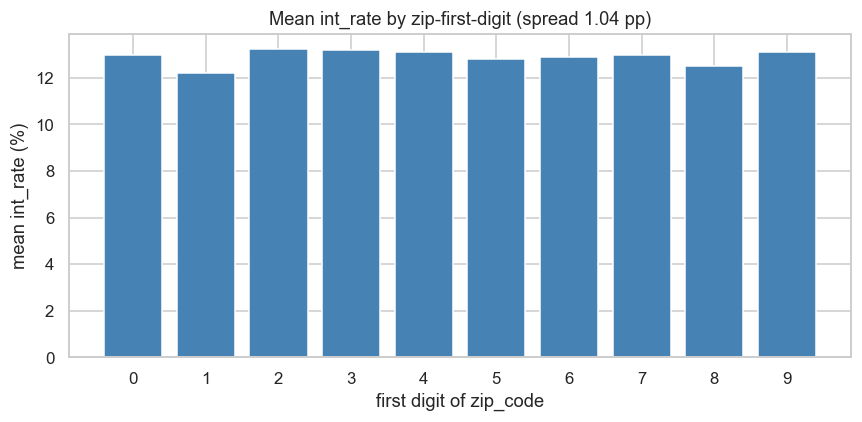

In [39]:
# Zip first-digit signal
zip_first = train.groupby("zip_first_digit")["int_rate"].agg(["mean", "count"]).sort_index()
print(f"zip first-digit spread: {zip_first['mean'].max() - zip_first['mean'].min():.3f} pp")
display(zip_first.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(zip_first.index, zip_first["mean"], color="steelblue")
ax.set_title(
    f"Mean int_rate by zip-first-digit "
    f"(spread {zip_first['mean'].max() - zip_first['mean'].min():.2f} pp)"
)
ax.set_ylabel("mean int_rate (%)")
ax.set_xlabel("first digit of zip_code")
save_fig("11_zip_first_digit")
plt.show()

In [40]:
# Zip nests within state? Check whether each zip3 maps to a single state.
nest = train.groupby("zip3")["addr_state"].nunique()
print(f"zip3 unique values: {len(nest)}")
print(f"zip3 mapping to >1 state: {(nest > 1).sum()}")
print(f"→ {'Perfectly nested' if (nest > 1).sum() == 0 else 'NOT perfectly nested'}")

zip3 unique values: 873
zip3 mapping to >1 state: 115
→ NOT perfectly nested


## 12. Data quality issues

The string-encoded columns have already been cast to numeric at load time (with `"NA"` → null). This section surveys the remaining quality concerns: extreme values, suspicious zeros, encoding edge cases.

In [41]:
ai = train["annual_inc"]
print(f"annual_inc summary:")
print(f"  median = ${ai.median():,.0f}")
print(f"  99th pctile = ${ai.quantile(0.99):,.0f}")
print(f"  max = ${ai.max():,.0f}")
print(f"  count > $1M = {(ai > 1_000_000).sum()}  ({(ai > 1_000_000).mean()*100:.2f}%)")
print()
print("Top 10 annual_inc values:")
display(train.nlargest(10, "annual_inc")[["annual_inc", "loan_amnt", "verification_status", "purpose", "int_rate"]])

annual_inc summary:
  median = $73,000
  99th pctile = $320,000
  max = $8,645,185
  count > $1M = 59  (0.06%)

Top 10 annual_inc values:


,annual_inc,loan_amnt,verification_status,purpose,int_rate
71163,8645185.0,40000,Verified,debt_consolidation,11.02
71889,7170646.0,6500,Verified,credit_card,11.02
15716,7072000.0,37500,Verified,credit_card,11.02
54229,6700000.0,21500,Verified,debt_consolidation,6.46
46902,6503700.0,24000,Verified,debt_consolidation,12.40
71809,6400029.0,18000,Verified,credit_card,13.08
27065,6220452.0,10000,Verified,debt_consolidation,17.74
46310,6150000.0,14000,Verified,debt_consolidation,11.02
68945,5683539.0,14400,Verified,debt_consolidation,17.74
98127,4016640.0,7000,Verified,credit_card,11.71


In [42]:
checks = pd.DataFrame([
    ["annual_inc == 0",   (train["annual_inc"] == 0).sum()],
    ["annual_inc isna",   train["annual_inc"].isna().sum()],
    ["dti == 0",          (train["dti"] == 0).sum()],
    ["dti < 0",           (train["dti"] < 0).sum()],
    ["dti > 100",         (train["dti"] > 100).sum()],
    ["revol_util == 0",   (train["revol_util"] == 0).sum()],
    ["revol_util > 150",  (train["revol_util"] > 150).sum()],
    ["loan_amnt == 0",    (train["loan_amnt"] == 0).sum()],
    ["loan > 5×annual_inc",
        ((train["loan_amnt"] > 5 * train["annual_inc"]) & (train["annual_inc"] > 0)).sum()],
    ["int_rate < 5",      (train["int_rate"] < 5).sum()],
    ["int_rate > 30",     (train["int_rate"] > 30).sum()],
    ["fico_range_low < 600",  (train["fico_range_low"] < 600).sum()],
    ["fico_range_low > 850",  (train["fico_range_low"] > 850).sum()],
], columns=["check", "n"])
display(checks)

,check,n
0,annual_inc == 0,186
1,annual_inc isna,0
2,dti == 0,74
3,dti < 0,0
4,dti > 100,392
5,revol_util == 0,756
6,revol_util > 150,2
7,loan_amnt == 0,0
8,loan > 5×annual_inc,45
9,int_rate < 5,0


In [43]:
# Confirm string-encoded numerics were parsed correctly
print("Dtype of formerly-string-encoded numeric columns:")
print(train[STRING_NUMERIC_COLS].dtypes.to_string())
print()
print("Their null counts (driven by 'NA' literals at load time):")
print(train[STRING_NUMERIC_COLS].isna().sum().to_string())

Dtype of formerly-string-encoded numeric columns:
dti                       float64
revol_util                float64
all_util                  float64
mo_sin_old_il_acct        float64
mths_since_last_record    float64
mths_since_rcnt_il        float64
mths_since_recent_bc      float64
mths_since_recent_inq     float64

Their null counts (driven by 'NA' literals at load time):
dti                         186
revol_util                  123
all_util                     16
mo_sin_old_il_acct         2204
mths_since_last_record    90875
mths_since_rcnt_il         2204
mths_since_recent_bc        920
mths_since_recent_inq      9975


## 13. Feature engineering hypotheses (catalog, no implementation)

What the EDA suggests building. Differences from the prior catalog: FICO becomes the primary main effect, `loan_status` does NOT appear (unavailable at application time), date-derived features are impossible (no `issue_d` / `earliest_cr_line`).

In [44]:
fe_hypotheses = pd.DataFrame([
    ["use fico (midpoint of low/high)",   "Largest non-leakage signal (§5)",            "fico = (low + high) / 2"],
    ["log transform: annual_inc",          "Skew >> 3 (§4)",                              "annual_inc_log"],
    ["log transform: revol_bal, tot_cur_bal, tot_coll_amt",
                                           "Heavy right tails (§4)",                      "*_log"],
    ["ratio: loan_to_income",              "Underwriting signal (§12)",                   "loan_to_income"],
    ["ratio: revol_util × loan_amnt",      "Bivariate non-linear (§6, §7)",               "interaction term"],
    ["interaction: fico × revol_util",     "Credit quality × utilization (§5, §6)",       "interaction term"],
    ["flag: selected is_missing_<col>",
                                           "Only when missingness rate and effect size justify it (§3)", "validate binary flags in CV"],
    ["flag: zero-inflated counters",       "pub_rec, delinq_2yrs, chargeoff/collection counters, tot_coll_amt (§4)",
                                                                                          "*_flag binaries"],
    ["bin: dti_bucket, loan_amnt_bucket",  "Discrete tree splits (§6)",                   "categorical bins"],
    ["addr_state native categorical",      "0.4-3pp main effect + interactions (§6, §11)", "pl.Categorical"],
    ["DROP: emp_title, title",             "emp_title high-cardinality; title duplicates purpose (§9)", "in DROP_COLS"],
    ["DROP: loan_status",                  "Unavailable at application time (§8)",         "already removed"],
    ["NOT POSSIBLE: temporal features",    "No issue_d in this dataset (§1)",             "—"],
], columns=["hypothesis", "motivation (EDA section)", "implementation"])
display(fe_hypotheses)

,hypothesis,motivation (EDA section),implementation
0,use fico (midpoint of low/high),Largest non-leakage signal (§5),fico = (low + high) / 2
1,log transform: annual_inc,Skew >> 3 (§4),annual_inc_log
2,"log transform: revol_bal, tot_cur_bal, tot_col...",Heavy right tails (§4),*_log
3,ratio: loan_to_income,Underwriting signal (§12),loan_to_income
4,ratio: revol_util × loan_amnt,"Bivariate non-linear (§6, §7)",interaction term
5,interaction: fico × revol_util,"Credit quality × utilization (§5, §6)",interaction term
6,flag: selected is_missing_<col>,Only when missingness rate and effect size jus...,validate binary flags in CV
7,flag: zero-inflated counters,"pub_rec, delinq_2yrs, chargeoff/collection cou...",*_flag binaries
8,"bin: dti_bucket, loan_amnt_bucket",Discrete tree splits (§6),categorical bins
9,addr_state native categorical,"0.4-3pp main effect + interactions (§6, §11)",pl.Categorical


## 14. Summary & modeling implications

### Top findings

1. **The data dictionary fully reconciles to train** — all 39 train columns are documented; test differs only by replacing `int_rate` with `ID` (§1).
2. **FICO is present and dominates non-leakage signal** — the prior `data/` slice was missing this column and the modeling ceiling was R² ≈ 0.52 as a result. FICO Spearman with `int_rate` is strongly negative; this dataset should support a substantially higher ceiling (§5).
3. **`loan_status` is unavailable at application time** — its marginal ANOVA effect is modest (eta-squared ≈ 0.44%), but it is current loan status rather than a borrower input. Dropped immediately on load (§8).
4. **`grade`, `sub_grade`, `installment` are absent** — the obvious pre-origination leakage trio is not in this slice. No need to drop them; the audit code from the prior notebook does not apply.
5. **No date columns** — neither `issue_d` nor `earliest_cr_line` exists. Temporal validation is impossible on this slice; use a random hold-out and accept that out-of-time generalization cannot be measured (§1, §5).
6. **Several numerics were string-encoded with literal `"NA"`** — `dti`, `revol_util`, `all_util`, `mo_sin_old_il_acct`, and four `mths_since_*` columns. Cast at load with `null_values=["NA"]` and Float64 overrides (§1, §12).
7. **`tot_cur_bal` dtype divergence between train and test** — Float64 vs Int64. Forced Float64 in both via `NUMERIC_OVERRIDES` (§1).
8. **Missingness flags should be selective** — `mths_since_recent_inq` and `mths_since_last_record` are the clearest candidates; low-missingness fields generally need imputation only (§3).
9. **Multicollinearity is mild** — only a few numeric pairs above |r|>0.7; `fico_range_low ↔ fico_range_high` is a near-duplicate by construction (diff is 4 for 99,986 rows and 5 for 14 rows); use the midpoint instead (§5, §7).
10. **State mean-rate spread is non-trivial** — but train/test drift is stronger for `loan_amnt`, `term`, and recent-credit-history fields (§10, §11).

### Pre-modeling checklist

- Drop `loan_status` unconditionally (already done at load).
- Drop `emp_title` (high-cardinality free text) and `title` (one-to-one duplicate of `purpose`).
- Parse `term` to integer months; map `emp_length` via `EMP_LENGTH_MAP`.
- Use `fico = (fico_range_low + fico_range_high) / 2` and drop the two raw columns to avoid the near-duplicate pair.
- Apply `log1p` to `annual_inc`, `revol_bal`, `tot_cur_bal`, `tot_coll_amt`.
- Add zero-inflated flags for `pub_rec`, `delinq_2yrs`, `chargeoff_within_12_mths`, `collections_12_mths_ex_med`, and `tot_coll_amt`.
- Add `is_missing_<col>` flags only for material missingness with non-trivial effect size, then keep only if CV improves (§3).
- Compute median imputation on train only; apply to val and test.
- Native XGBoost categoricals: `addr_state`, `home_ownership`, `verification_status`, `purpose`, `term`.
- **Validation: random split** (e.g. 80/20). No temporal column exists.

### Honest expectations

- With FICO present, validation R² should be materially higher than the prior FICO-stripped slice, but quote the ceiling only after running the random holdout model.
- The largest residual signal lives in `revol_util` and `dti` after FICO is conditioned out.
- Out-of-time generalization is **unmeasured** on this slice. If the model is deployed, monitor live performance against expected RMSE — drift can only be detected post-hoc.

### Risk register

Features with PSI ≥ 0.1 (train vs test, §10) are most exposed to whatever sampling mechanism produced the test split. If the model is retrained, recompute imputation medians.

In [45]:
print("EDA complete. Figures written to outputs/eda/:")
for p in sorted(OUTPUT_DIR.glob('*.png')):
    print(f"  {p.name}")
print(f"\nTotal: {len(list(OUTPUT_DIR.glob('*.png')))} figures")

EDA complete. Figures written to outputs/eda/:
  02_target_distribution.png
  03_missingness_cooccurrence.png
  03_missingness_matrix.png
  03_missingness_top15.png
  04_categorical_counts.png
  04_numeric_histograms.png
  05_fico_analysis.png
  06_bivariate_hexbin.png
  06_categorical_boxplots.png
  06_state_bar.png
  07_correlation_heatmap.png
  08_loan_status_leakage.png
  10_drift_kde.png
  11_zip_first_digit.png

Total: 14 figures
